In [221]:
# !pip install polars
# !pip install xlsxwriter

In [222]:
from IPython import get_ipython
get_ipython().run_line_magic('reset', '-f')

# Import datasets


In [223]:
import polars as pl

general_information = pl.read_csv('data/general_information_bkp.csv', infer_schema_length=None, ignore_errors=True)
type_and_level = pl.read_csv('data/type_and_level_bk.csv', infer_schema_length=None, ignore_errors=True)
geographical_facilities = pl.read_csv('data/geographical_facilities_bkp.csv', infer_schema_length=None, ignore_errors=True)
buildings_and_library = pl.read_csv('data/buildings_and_library.csv', infer_schema_length=None, ignore_errors=True)
compliance1 = pl.read_csv('data/compliance_1_bkp.csv', infer_schema_length=None, ignore_errors=True)
compliance2 = pl.read_csv('data/compliance_2_bkp.csv', infer_schema_length=None, ignore_errors=True)
compliance3 = pl.read_csv('data/compliance_3_bkp.csv', infer_schema_length=None, ignore_errors=True)
compliance4 = pl.read_csv('data/compliance_4_bkp.csv', infer_schema_length=None, ignore_errors=True)
divisions = pl.read_csv('data/divisions_bkp.csv', infer_schema_length=None, ignore_errors=True)
districts = pl.read_csv('data/districts_bkp.csv', infer_schema_length=None, ignore_errors=True)
thanas = pl.read_csv('data/thanas_bkp.csv', infer_schema_length=None, ignore_errors=True)
pbgsi_institutions = pl.read_csv('data/pbgsi_7000_ins_bkp.csv', infer_schema_length=None, ignore_errors=True)
institute_type = pl.read_csv('configs/institution_type.csv', infer_schema_length=None, ignore_errors=True)
student_type = pl.read_csv('configs/student_types.csv', infer_schema_length=None, ignore_errors=True)
divisions = pl.read_csv('data/divisions_bkp.csv', infer_schema_length=None, ignore_errors=True)
districts = pl.read_csv('data/districts_bkp.csv', infer_schema_length=None, ignore_errors=True)
thanas = pl.read_csv('data/thanas_bkp.csv', infer_schema_length=None, ignore_errors=True)
approval_status = pl.read_csv('configs/approval_status.csv', infer_schema_length=None, ignore_errors=True)
boards = pl.read_csv('configs/boards.csv', infer_schema_length=None, ignore_errors=True)
boundary_types = pl.read_csv('configs/boundary_type.csv', infer_schema_length=None, ignore_errors=True)
emis_submission_types = pl.read_csv('configs/emis_submission_types.csv', infer_schema_length=None, ignore_errors=True)
fiscal_years = pl.read_csv('configs/fiscal_years.csv', infer_schema_length=None, ignore_errors=True)
geographical_location_types = pl.read_csv('configs/geographical_locations_type.csv', infer_schema_length=None, ignore_errors=True)
highest_levels = pl.read_csv('configs/higest_levels.csv',infer_schema_length=None, ignore_errors=True)
management_type = pl.read_csv('configs/management_types.csv', infer_schema_length=None, ignore_errors=True)
mpo_status = pl.read_csv('configs/mpo_status.csv', infer_schema_length=None, ignore_errors=True)
ownership_types = pl.read_csv('configs/ownership_type.csv', infer_schema_length=None, ignore_errors=True)
pass_rate_types = pl.read_csv('configs/pass_rate_type.csv', infer_schema_length=None, ignore_errors=True)
sexual_harassment_committee_activity_type = pl.read_csv('configs/sexual_harassment_committee_activity_type.csv', infer_schema_length=None, ignore_errors=True)
students_attendance_types = pl.read_csv('configs/students_attendance_type.csv', infer_schema_length=None, ignore_errors=True)
teachers_attendance_types = pl.read_csv('configs/teachers_attendance_type.csv', infer_schema_length=None, ignore_errors=True)
technical_types = pl.read_csv('configs/technical_type.csv', infer_schema_length=None, ignore_errors=True)
ward_type = pl.read_csv('configs/ward_type.csv', infer_schema_length=None, ignore_errors=True)

# Generate Column Names

In [224]:
df_vars = {
    name: val
    for name, val  in globals().items()
    if isinstance(val, (pl.DataFrame, pl.LazyFrame))
}

In [225]:
from pathlib import Path

out_dir = Path.cwd() / "generate"
out_dir.mkdir(parents=True, exist_ok=True)

In [226]:
for name, val  in df_vars.items():
    with open("generate/" + name +".py", "w") as f:
        for col in val.columns:
            safe_col = col.strip().replace(" ", "_").replace("-","_").replace("[","").replace("]","")
            f.write(f'{safe_col.upper()}="{col}"\n')

In [227]:
import importlib

def update_columns(dataframe_name: str):
    df_vars = {
    name: val
    for name, val  in globals().items()
    if isinstance(val, (pl.DataFrame, pl.LazyFrame))
    }
    for name, val  in df_vars.items():
        if name == dataframe_name:
            print('found match')
            with open("generate/" + name +".py", "w") as f:
                for col in val.columns:
                    safe_col = col.strip().replace(" ", "_").replace("-","_").replace("[","").replace("]","")
                    f.write(f'{safe_col.upper()}="{col}"\n')
            print('column names updated')
            module = importlib.import_module('generate.'+dataframe_name)
            importlib.reload(module)

Consider only submitted institutions

In [228]:
from generate.general_information import SUBMITTED

general_information = general_information.filter(pl.col(SUBMITTED) == 1)


Join general information with Type and Level, Geographical Facilities, Compliance1, Compliance2, Compliance3, Compliance4

In [229]:
general_information = general_information.join(type_and_level, left_on=general_information['eiin'].name, right_on=type_and_level['eiin'].name, how="inner", suffix='_type_and_level')
general_information = general_information.join(geographical_facilities, left_on=general_information['eiin'].name, right_on=geographical_facilities['eiin'].name, how="inner", suffix='_geographical_facilities')
general_information = general_information.join(compliance1, left_on=general_information['eiin'].name, right_on=compliance1['eiin'].name, how='inner', suffix='_compliance1')
general_information = general_information.join(compliance2, left_on=general_information['eiin'].name, right_on=compliance2['eiin'].name, how='inner', suffix='_compliance2')
general_information = general_information.join(compliance3, left_on=general_information['eiin'].name, right_on=compliance3['eiin'].name, how='left', suffix='_compliance3')
general_information = general_information.join(compliance4, left_on=general_information['eiin'].name, right_on=compliance4['eiin'].name, how='inner', suffix='_compliance4')

Update the generated column names of general_information

In [230]:
update_columns('general_information')

found match
column names updated


Filter only pubgsi submitted institutions

Join general_information with institute_type, student_type, divisions, districts, thanas, geographical_location_types

In [231]:
general_information = general_information.join(institute_type, left_on=general_information['institution_type'].name, right_on=institute_type['institute_type_id'].name, how='inner', suffix='_institution_type')
general_information = general_information.join(student_type, left_on=general_information['student_type'].name, right_on=student_type['student_type_id'].name, how='inner', suffix='_student_type')
general_information = general_information.join(divisions, left_on=general_information['address_division'].name, right_on=divisions['division_id'].name, how='inner', suffix='_division')
general_information = general_information.join(districts, left_on=general_information['address_district'].name, right_on=districts['district_id'].name, how='inner', suffix='_district')
general_information = general_information.join(thanas, left_on=general_information['address_thana'].name, right_on=thanas['thana_id'].name, how='inner', suffix='_thana')
general_information = general_information.join(geographical_location_types, left_on=geographical_facilities['geographical_position'].name, right_on=geographical_location_types['geographical_location_id'].name, how='inner', suffix='_geographical_location_type')

In [232]:
general_information_bkp = general_information.clone()
general_information_submitted = general_information.clone()

In [233]:
from generate.general_information import PBGSI_SCHEME

general_information = general_information.filter(pl.col(PBGSI_SCHEME) == True)

In [234]:
update_columns('general_information')

found match
column names updated


In [235]:
from generate.general_information import PBSCI_FISCAL_YEAR, EIIN, MPO_STATUS

general_information = general_information.filter(pl.col(PBSCI_FISCAL_YEAR).is_in(['2022-2023', '2023-2024']))
general_information = general_information.filter(pl.col(MPO_STATUS)==1)

In [236]:
general_information.head(5)

id,institution_name_bangla,institution_name_english,address_village_holding,address_road,address_post_office,address_post_code,[union],address_ward,address_thana,address_district,address_division,mobile_number,picture,latitude,longitude,ownership_type,is_owned_land,has_deed,has_mutation,pays_taxes,academic_activities_running,eiin_yes_no,eiin,non_eiin_id,horizontal_accuracy,vertical_accuracy,position_time,inst_category,establishment_date,union_ward,municipility,municipility_ward,union,city_corporation,city_corporation_ward,ward_type,…,ninth_grade_books_issued_count,ninth_grade_books_received,tenth_grade_books_issued_count,tenth_grade_books_received,manual_distributed,distribution_info_sent,visited,visited_by_monitoring_officer,visited_by_scheme_officer,visited_by_maushi,visited_by_others,books_received_on,sixth_grade_books_provided,seventh_grade_books_provided,eighth_grade_books_provided,ninth_grade_books_provided,tenth_grade_books_provided,institute_type_name,institute_type_name_en,student_type_name,student_type_name_en,division_id_legacy,division_name,division_name_bn,division_code,district_id_legacy,district_name,district_name_bn,division_id,district_code,thana_code,thana_id_legacy,thana_name,thana_name_bn,district_id,city_corp,geographical_location_name
i64,str,str,str,str,str,str,str,str,i64,i64,i64,str,str,f64,f64,str,bool,bool,bool,bool,bool,str,str,i64,f64,f64,str,i64,str,str,str,i64,str,str,i64,bool,…,i64,i64,i64,i64,bool,bool,bool,bool,bool,bool,bool,str,i64,i64,i64,i64,i64,str,str,str,str,i64,str,str,i64,i64,str,str,i64,i64,str,i64,str,str,i64,str,str
199041,"""তেলিখাল উচ্চ বিদ্যালয়""","""TELIKHAL HIGH SCHOOL""","""TELEKHAL""",null,null,null,null,null,129,63,7,"""01309130228""","""130228_20250811_044030.jpg""",25.074261,91.77726,"""OWN""",false,true,true,true,true,null,"""130228""",null,9.483,7.418218,null,1,"""01-01-1998""",null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""স্কুল""","""SCHOOL""","""সহশিক্ষা""","""Co-education""",60,"""Sylhet""","""সিলেট""",6,6091,"""Sylhet""","""সিলেট""",7,91,"""6091""",609127,"""Companiganj""","""কোম্পানীগঞ্জ""",63,null,"""হাওড়/ বিল"""
194031,"""উজগ্রাম পিন্টু বালিকা উচ্চ বিদ…","""UZGRAM PINTU GIRLS HIGH SCHOOL""","""UZGRAM""","""0""","""Langluhat""","""5820""",null,null,184,7,6,"""01309119506""","""119506_20250811_053432.jpg""",24.988141,89.428448,"""OWN""",false,true,true,true,true,null,"""119506""",null,4.7,20.734821,null,1,"""14-01-1987""","""8""",null,null,"""11 num.Dakkhinpara""",null,null,true,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""স্কুল""","""SCHOOL""","""মেয়ে""","""Girl""",50,"""Rajshahi""","""রাজশাহী""",5,5010,"""Bogura""","""বগুড়া""",6,10,"""5010""",501040,"""Gabtali""","""গাবতলী""",7,null,"""সমতল """
195117,"""কৃষ্ণারডাঙ্গী উচ্চ বিদ্যালয়""","""KRISHNAR DANGI HIGH SCHOOL""","""KRISHNAR DANGI""","""Faridpur Sadarpur Road""","""Kunjanagar""","""7821""",null,null,383,16,4,"""01309108863""","""108863_20250811_080457.jpg""",23.554668,89.90374,"""OWN""",false,true,true,true,true,null,"""108863""",null,4.3,2.305418,null,1,"""01-01-1960""","""2""",null,null,"""Ramnagar""",null,null,true,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""স্কুল""","""SCHOOL""","""সহশিক্ষা""","""Co-education""",30,"""Dhaka""","""ঢাকা""",3,3029,"""Faridpur""","""ফরিদপুর""",4,29,"""3029""",302962,"""Nagarkanda""","""নগরকান্দা""",16,null,"""সমতল """
192170,"""আলমদস্তার আদর্শ উচ্চ বিদ্যালয়""","""ALMODASTAR ADARSHA HIGH SCHOOL""","""ALOMDASTER 06 NO WORD""",null,"""Rajoir""","""7910""",null,null,452,34,4,"""01309110810""","""110810_20250813_062758.jpg""",23.205007,90.039962,"""OWN""",false,true,true,true,true,null,"""110810""",null,4.287,3.032601,null,1,"""03-09-1995""",null,"""Rajoir""",6,null,null,null,true,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""স্কুল""","""SCHOOL""","""সহশিক্ষা""","""Co-e

In [237]:
general_information['institute_type_name_en'].head()

institute_type_name_en
str
"""SCHOOL"""
"""SCHOOL"""
"""SCHOOL"""
"""SCHOOL"""
"""SCHOOL"""
"""SCHOOL"""
"""MADRASHA"""
"""SCHOOL"""
"""SCHOOL"""


Merge college and school & college for the purpose of the report

In [238]:
# first we copy the columns to new columns
general_information = general_information.with_columns([
    pl.col('institution_type').alias('generalized_institution_type_id'),
    pl.col('institute_type_name_en').alias('generalized_institution_type_name_en')
])

In [239]:
update_columns('general_information')

found match
column names updated


In [240]:
general_information.head()

id,institution_name_bangla,institution_name_english,address_village_holding,address_road,address_post_office,address_post_code,[union],address_ward,address_thana,address_district,address_division,mobile_number,picture,latitude,longitude,ownership_type,is_owned_land,has_deed,has_mutation,pays_taxes,academic_activities_running,eiin_yes_no,eiin,non_eiin_id,horizontal_accuracy,vertical_accuracy,position_time,inst_category,establishment_date,union_ward,municipility,municipility_ward,union,city_corporation,city_corporation_ward,ward_type,…,tenth_grade_books_issued_count,tenth_grade_books_received,manual_distributed,distribution_info_sent,visited,visited_by_monitoring_officer,visited_by_scheme_officer,visited_by_maushi,visited_by_others,books_received_on,sixth_grade_books_provided,seventh_grade_books_provided,eighth_grade_books_provided,ninth_grade_books_provided,tenth_grade_books_provided,institute_type_name,institute_type_name_en,student_type_name,student_type_name_en,division_id_legacy,division_name,division_name_bn,division_code,district_id_legacy,district_name,district_name_bn,division_id,district_code,thana_code,thana_id_legacy,thana_name,thana_name_bn,district_id,city_corp,geographical_location_name,generalized_institution_type_id,generalized_institution_type_name_en
i64,str,str,str,str,str,str,str,str,i64,i64,i64,str,str,f64,f64,str,bool,bool,bool,bool,bool,str,str,i64,f64,f64,str,i64,str,str,str,i64,str,str,i64,bool,…,i64,i64,bool,bool,bool,bool,bool,bool,bool,str,i64,i64,i64,i64,i64,str,str,str,str,i64,str,str,i64,i64,str,str,i64,i64,str,i64,str,str,i64,str,str,i64,str
199041,"""তেলিখাল উচ্চ বিদ্যালয়""","""TELIKHAL HIGH SCHOOL""","""TELEKHAL""",null,null,null,null,null,129,63,7,"""01309130228""","""130228_20250811_044030.jpg""",25.074261,91.77726,"""OWN""",false,true,true,true,true,null,"""130228""",null,9.483,7.418218,null,1,"""01-01-1998""",null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""স্কুল""","""SCHOOL""","""সহশিক্ষা""","""Co-education""",60,"""Sylhet""","""সিলেট""",6,6091,"""Sylhet""","""সিলেট""",7,91,"""6091""",609127,"""Companiganj""","""কোম্পানীগঞ্জ""",63,null,"""হাওড়/ বিল""",1,"""SCHOOL"""
194031,"""উজগ্রাম পিন্টু বালিকা উচ্চ বিদ…","""UZGRAM PINTU GIRLS HIGH SCHOOL""","""UZGRAM""","""0""","""Langluhat""","""5820""",null,null,184,7,6,"""01309119506""","""119506_20250811_053432.jpg""",24.988141,89.428448,"""OWN""",false,true,true,true,true,null,"""119506""",null,4.7,20.734821,null,1,"""14-01-1987""","""8""",null,null,"""11 num.Dakkhinpara""",null,null,true,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""স্কুল""","""SCHOOL""","""মেয়ে""","""Girl""",50,"""Rajshahi""","""রাজশাহী""",5,5010,"""Bogura""","""বগুড়া""",6,10,"""5010""",501040,"""Gabtali""","""গাবতলী""",7,null,"""সমতল """,1,"""SCHOOL"""
195117,"""কৃষ্ণারডাঙ্গী উচ্চ বিদ্যালয়""","""KRISHNAR DANGI HIGH SCHOOL""","""KRISHNAR DANGI""","""Faridpur Sadarpur Road""","""Kunjanagar""","""7821""",null,null,383,16,4,"""01309108863""","""108863_20250811_080457.jpg""",23.554668,89.90374,"""OWN""",false,true,true,true,true,null,"""108863""",null,4.3,2.305418,null,1,"""01-01-1960""","""2""",null,null,"""Ramnagar""",null,null,true,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""স্কুল""","""SCHOOL""","""সহশিক্ষা""","""Co-education""",30,"""Dhaka""","""ঢাকা""",3,3029,"""Faridpur""","""ফরিদপুর""",4,29,"""3029""",302962,"""Nagarkanda""","""নগরকান্দা""",16,null,"""সমতল """,1,"""SCHOOL"""
192170,"""আলমদস্তার আদর্শ উচ্চ বিদ্যালয়""","""ALMODASTAR ADARSHA HIGH SCHOOL""","""ALOMDASTER 06 NO WORD""",null,"""Rajoir""","""7910""",null,null,452,34,4,"""01309110810""","""110810_20250813_062758.jpg""",23.205007,90.039962,"""OWN""",false,true,true,true,true,null,"""110810""",null,4.287,3.032601,null,1,"""03-09-1995""",null,"""Rajoir""",6,null,null,null,true,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""স্কুল""","""SCHOOL""","""সহশ

In [241]:

# when we get the college type, we change the type to school & college

condition = pl.col(general_information['generalized_institution_type_id'].name)==3

general_information = general_information.with_columns([
    pl.when(condition)
    .then(pl.lit(2))
    .otherwise(pl.col(general_information['generalized_institution_type_id'].name))
    .alias('generalized_institution_type_id'),
    
    pl.when(condition)
    .then(pl.lit('SCHOOL AND COLLEGE'))
    .otherwise(pl.col(general_information['generalized_institution_type_name_en'].name))
    .alias('generalized_institution_type_name_en')
])

In [242]:
general_information.head()

id,institution_name_bangla,institution_name_english,address_village_holding,address_road,address_post_office,address_post_code,[union],address_ward,address_thana,address_district,address_division,mobile_number,picture,latitude,longitude,ownership_type,is_owned_land,has_deed,has_mutation,pays_taxes,academic_activities_running,eiin_yes_no,eiin,non_eiin_id,horizontal_accuracy,vertical_accuracy,position_time,inst_category,establishment_date,union_ward,municipility,municipility_ward,union,city_corporation,city_corporation_ward,ward_type,…,tenth_grade_books_issued_count,tenth_grade_books_received,manual_distributed,distribution_info_sent,visited,visited_by_monitoring_officer,visited_by_scheme_officer,visited_by_maushi,visited_by_others,books_received_on,sixth_grade_books_provided,seventh_grade_books_provided,eighth_grade_books_provided,ninth_grade_books_provided,tenth_grade_books_provided,institute_type_name,institute_type_name_en,student_type_name,student_type_name_en,division_id_legacy,division_name,division_name_bn,division_code,district_id_legacy,district_name,district_name_bn,division_id,district_code,thana_code,thana_id_legacy,thana_name,thana_name_bn,district_id,city_corp,geographical_location_name,generalized_institution_type_id,generalized_institution_type_name_en
i64,str,str,str,str,str,str,str,str,i64,i64,i64,str,str,f64,f64,str,bool,bool,bool,bool,bool,str,str,i64,f64,f64,str,i64,str,str,str,i64,str,str,i64,bool,…,i64,i64,bool,bool,bool,bool,bool,bool,bool,str,i64,i64,i64,i64,i64,str,str,str,str,i64,str,str,i64,i64,str,str,i64,i64,str,i64,str,str,i64,str,str,i64,str
199041,"""তেলিখাল উচ্চ বিদ্যালয়""","""TELIKHAL HIGH SCHOOL""","""TELEKHAL""",null,null,null,null,null,129,63,7,"""01309130228""","""130228_20250811_044030.jpg""",25.074261,91.77726,"""OWN""",false,true,true,true,true,null,"""130228""",null,9.483,7.418218,null,1,"""01-01-1998""",null,null,null,null,null,null,null,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""স্কুল""","""SCHOOL""","""সহশিক্ষা""","""Co-education""",60,"""Sylhet""","""সিলেট""",6,6091,"""Sylhet""","""সিলেট""",7,91,"""6091""",609127,"""Companiganj""","""কোম্পানীগঞ্জ""",63,null,"""হাওড়/ বিল""",1,"""SCHOOL"""
194031,"""উজগ্রাম পিন্টু বালিকা উচ্চ বিদ…","""UZGRAM PINTU GIRLS HIGH SCHOOL""","""UZGRAM""","""0""","""Langluhat""","""5820""",null,null,184,7,6,"""01309119506""","""119506_20250811_053432.jpg""",24.988141,89.428448,"""OWN""",false,true,true,true,true,null,"""119506""",null,4.7,20.734821,null,1,"""14-01-1987""","""8""",null,null,"""11 num.Dakkhinpara""",null,null,true,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""স্কুল""","""SCHOOL""","""মেয়ে""","""Girl""",50,"""Rajshahi""","""রাজশাহী""",5,5010,"""Bogura""","""বগুড়া""",6,10,"""5010""",501040,"""Gabtali""","""গাবতলী""",7,null,"""সমতল """,1,"""SCHOOL"""
195117,"""কৃষ্ণারডাঙ্গী উচ্চ বিদ্যালয়""","""KRISHNAR DANGI HIGH SCHOOL""","""KRISHNAR DANGI""","""Faridpur Sadarpur Road""","""Kunjanagar""","""7821""",null,null,383,16,4,"""01309108863""","""108863_20250811_080457.jpg""",23.554668,89.90374,"""OWN""",false,true,true,true,true,null,"""108863""",null,4.3,2.305418,null,1,"""01-01-1960""","""2""",null,null,"""Ramnagar""",null,null,true,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""স্কুল""","""SCHOOL""","""সহশিক্ষা""","""Co-education""",30,"""Dhaka""","""ঢাকা""",3,3029,"""Faridpur""","""ফরিদপুর""",4,29,"""3029""",302962,"""Nagarkanda""","""নগরকান্দা""",16,null,"""সমতল """,1,"""SCHOOL"""
192170,"""আলমদস্তার আদর্শ উচ্চ বিদ্যালয়""","""ALMODASTAR ADARSHA HIGH SCHOOL""","""ALOMDASTER 06 NO WORD""",null,"""Rajoir""","""7910""",null,null,452,34,4,"""01309110810""","""110810_20250813_062758.jpg""",23.205007,90.039962,"""OWN""",false,true,true,true,true,null,"""110810""",null,4.287,3.032601,null,1,"""03-09-1995""",null,"""Rajoir""",6,null,null,null,true,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""স্কুল""","""SCHOOL""","""সহশ

In [243]:
student_type.head()

student_type_id,student_type_name,student_type_name_en
i64,str,str
1,"""ছেলে""","""Boy"""
2,"""মেয়ে""","""Girl"""
3,"""সহশিক্ষা""","""Co-education"""


## Table 1. Number of secondary institutions havign management accoutability grant by type of institution and gender composition
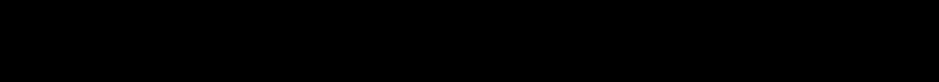
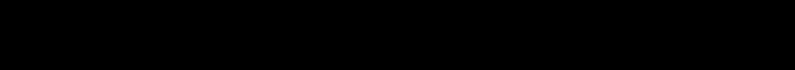
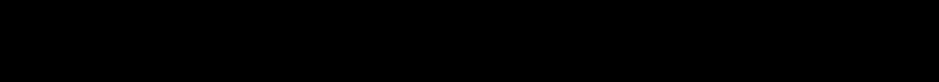

In [244]:
report1 = (
    general_information.lazy()
    .group_by(pl.col('generalized_institution_type_name_en').alias('institution_type'))
    .agg([
         pl.len().alias('total'),
         (pl.col('student_type')==1).sum().alias('total_boys'),
         (pl.col('student_type')==2).sum().alias('total_girls'),
         (pl.col('student_type')==3).sum().alias('co-education')
    ])
)

report1_df = report1.collect()
report1_df.head(100)

institution_type,total,total_boys,total_girls,co-education
str,u32,u32,u32,u32
"""QAOMI MADRASHA""",1,0,1,0
"""SCHOOL AND COLLEGE""",535,2,81,452
"""TECHNICAL AND VOCATIONAL""",14,0,1,13
"""SCHOOL""",4979,55,721,4203
"""MADRASHA""",1848,5,161,1682


In [245]:
report1_df.write_excel('output/table1.xlsx')

## Table 2. Distribution of secondary institutions having Management Accountability Grant by Division and type of institution

In [246]:
institute_type.head(10)

institute_type_id,institute_type_name,institute_type_name_en
i64,str,str
1,"""স্কুল""","""SCHOOL"""
2,"""স্কুল এন্ড কলেজ""","""SCHOOL AND COLLEGE"""
3,"""কলেজ""","""COLLEGE"""
4,"""মাদ্রাসা""","""MADRASHA"""
5,"""কওমী মাদ্রাসা""","""QAOMI MADRASHA"""
6,"""কারিগরি ও ভোকেশনাল""","""TECHNICAL AND VOCATIONAL"""


In [247]:
from generate.general_information import DIVISION_NAME, GENERALIZED_INSTITUTION_TYPE_NAME_EN, GENERALIZED_INSTITUTION_TYPE_ID
institution_type_school = 1
institution_type_school_and_college = 2
institution_type_madrasha = 4

report2 = (
    general_information.lazy()
    .group_by(pl.col(DIVISION_NAME).alias("Division"))
    .agg([
      (pl.col(GENERALIZED_INSTITUTION_TYPE_ID)== institution_type_school).sum().alias('Secondary School'),
      (pl.col(GENERALIZED_INSTITUTION_TYPE_ID)==institution_type_school_and_college).sum().alias('School & College'),
      (pl.col(GENERALIZED_INSTITUTION_TYPE_ID)== institution_type_madrasha).sum().alias('Madrasha')
    ])
)

report2_df = report2.collect()
report2_df.head(10)

Division,Secondary School,School & College,Madrasha
str,u32,u32,u32
"""Chattogram""",984,87,367
"""Mymensingh""",290,29,111
"""Rajshahi""",587,55,283
"""Barishal""",582,49,319
"""Sylhet""",274,68,84
"""Dhaka""",936,133,282
"""Rangpur""",632,69,207
"""Khulna""",694,45,195


Add percentage

In [248]:
report2_df = report2_df.with_columns([
    ((pl.col('Secondary School')/(pl.col('Secondary School') + pl.col('School & College') + pl.col('Madrasha'))) * 100).round(2).alias('school percentage'),
    ((pl.col('School & College')/(pl.col('Secondary School') + pl.col('School & College') + pl.col('Madrasha'))) * 100).round(2).alias('school & college percentage'),
    ((pl.col('Madrasha')/(pl.col('Secondary School') + pl.col('School & College') + pl.col('Madrasha'))) * 100).round(2).alias('madrasha percentage')
])

In [249]:
report2_df.head(10)

Division,Secondary School,School & College,Madrasha,school percentage,school & college percentage,madrasha percentage
str,u32,u32,u32,f64,f64,f64
"""Chattogram""",984,87,367,68.43,6.05,25.52
"""Mymensingh""",290,29,111,67.44,6.74,25.81
"""Rajshahi""",587,55,283,63.46,5.95,30.59
"""Barishal""",582,49,319,61.26,5.16,33.58
"""Sylhet""",274,68,84,64.32,15.96,19.72
"""Dhaka""",936,133,282,69.28,9.84,20.87
"""Rangpur""",632,69,207,69.6,7.6,22.8
"""Khulna""",694,45,195,74.3,4.82,20.88


In [250]:
report2_df = report2_df.sort('Division', descending=False)

In [251]:
report2_df.head(10)

Division,Secondary School,School & College,Madrasha,school percentage,school & college percentage,madrasha percentage
str,u32,u32,u32,f64,f64,f64
"""Barishal""",582,49,319,61.26,5.16,33.58
"""Chattogram""",984,87,367,68.43,6.05,25.52
"""Dhaka""",936,133,282,69.28,9.84,20.87
"""Khulna""",694,45,195,74.3,4.82,20.88
"""Mymensingh""",290,29,111,67.44,6.74,25.81
"""Rajshahi""",587,55,283,63.46,5.95,30.59
"""Rangpur""",632,69,207,69.6,7.6,22.8
"""Sylhet""",274,68,84,64.32,15.96,19.72


In [252]:
report2_df = report2_df.select(['Division', 'Secondary School', 'school percentage', 'School & College', 'school & college percentage', 'Madrasha', 'madrasha percentage'])

In [253]:
report2_df.head(10)

Division,Secondary School,school percentage,School & College,school & college percentage,Madrasha,madrasha percentage
str,u32,f64,u32,f64,u32,f64
"""Barishal""",582,61.26,49,5.16,319,33.58
"""Chattogram""",984,68.43,87,6.05,367,25.52
"""Dhaka""",936,69.28,133,9.84,282,20.87
"""Khulna""",694,74.3,45,4.82,195,20.88
"""Mymensingh""",290,67.44,29,6.74,111,25.81
"""Rajshahi""",587,63.46,55,5.95,283,30.59
"""Rangpur""",632,69.6,69,7.6,207,22.8
"""Sylhet""",274,64.32,68,15.96,84,19.72


In [254]:
report2_df.write_excel('output/table2.xlsx')

## Table 3. Number of Secondary Institutions received Management Accountability Grant having Toilet Facilities for students by type of institution

In [255]:
from generate.general_information import GENERALIZED_INSTITUTION_TYPE_NAME_EN, HAS_STUDENT_TOILET, TOTAL_TOILET_FOR_BOYS, TOTAL_TOILET_FOR_GIRLS, TOTAL_TOILET_FOR_SPECIAL_NEEDS

report3 = (
    general_information.lazy()
    .group_by(pl.col(GENERALIZED_INSTITUTION_TYPE_NAME_EN).alias('institution_type'))
    .agg([
        (pl.col(HAS_STUDENT_TOILET)==1).sum().alias('toilet_yes'),
        (pl.col(HAS_STUDENT_TOILET)==0).sum().alias('toilet_no'),
        (pl.col(TOTAL_TOILET_FOR_BOYS)==1).sum().alias('boys_1'),
        (pl.col(TOTAL_TOILET_FOR_BOYS)==2).sum().alias('boys_2'),
        (pl.col(TOTAL_TOILET_FOR_BOYS)>2).sum().alias('boys_2_plus'),
        (pl.col(TOTAL_TOILET_FOR_BOYS).is_null() | pl.col(TOTAL_TOILET_FOR_BOYS)==0).sum().alias('boys_none'),
        (pl.col(TOTAL_TOILET_FOR_GIRLS)==1).sum().alias('girls_1'),
        (pl.col(TOTAL_TOILET_FOR_GIRLS)==2).sum().alias('girls_2'),
        (pl.col(TOTAL_TOILET_FOR_GIRLS)>2).sum().alias('girls_2_plus'),
        (pl.col(TOTAL_TOILET_FOR_GIRLS).is_null() | pl.col(TOTAL_TOILET_FOR_GIRLS)==0).sum().alias('girls_none'),
        (pl.col(TOTAL_TOILET_FOR_SPECIAL_NEEDS)>=1).sum().alias('special_needs_toilet'),
        (pl.col(TOTAL_TOILET_FOR_SPECIAL_NEEDS).is_null() | pl.col(TOTAL_TOILET_FOR_SPECIAL_NEEDS)==0).sum().alias('special_needs_none')
    ])
)

report3_df = report3.collect()
report3_df.head(100)

institution_type,toilet_yes,toilet_no,boys_1,boys_2,boys_2_plus,boys_none,girls_1,girls_2,girls_2_plus,girls_none,special_needs_toilet,special_needs_none
str,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
"""SCHOOL""",4942,37,704,1093,2389,761,769,1111,2979,87,1505,3441
"""QAOMI MADRASHA""",1,0,0,0,0,1,0,0,1,0,0,1
"""MADRASHA""",1837,11,464,469,729,177,507,538,777,17,468,1370
"""SCHOOL AND COLLEGE""",535,0,40,72,339,84,44,83,405,3,171,364
"""TECHNICAL AND VOCATIONAL""",14,0,7,3,2,2,7,3,3,1,3,11


In [256]:
report3_df.write_excel('output/table3.xlsx')

## Table 4. Number of Secondary Institutions received Management Accountability Grant having Toilet Facilities for teachers by type of institution

In [257]:
from generate.general_information import GENERALIZED_INSTITUTION_TYPE_NAME_EN, HAS_TEACHER_TOILET, TOTAL_TOILET_FOR_MALE_TEACHERS, TOTAL_TOILET_FOR_FEMALE_TEACHERS, TOTAL_TOILET_FOR_COMMONS

report4 = (
    general_information.lazy()
    .group_by(pl.col(GENERALIZED_INSTITUTION_TYPE_NAME_EN).alias('institution_type'))
    .agg([
        (pl.col(HAS_TEACHER_TOILET)==1).sum().alias('toilet_yes'),
        (pl.col(HAS_TEACHER_TOILET)==0).sum().alias('toilet_no'),
        (pl.col(TOTAL_TOILET_FOR_MALE_TEACHERS)==1).sum().alias('male_1'),
        (pl.col(TOTAL_TOILET_FOR_MALE_TEACHERS)>=2).sum().alias('male_2_plus'),
        (pl.col(TOTAL_TOILET_FOR_MALE_TEACHERS).is_null() | pl.col(TOTAL_TOILET_FOR_MALE_TEACHERS)==0).sum().alias('male_none'),
        (pl.col(TOTAL_TOILET_FOR_FEMALE_TEACHERS)==1).sum().alias('female_1'),
        (pl.col(TOTAL_TOILET_FOR_FEMALE_TEACHERS)>=2).sum().alias('female_2_plus'),
        (pl.col(TOTAL_TOILET_FOR_FEMALE_TEACHERS).is_null() | pl.col(TOTAL_TOILET_FOR_FEMALE_TEACHERS)==0 ).sum().alias('female_none'),
        (pl.col(TOTAL_TOILET_FOR_COMMONS)==1).sum().alias('common_1'),
        (pl.col(TOTAL_TOILET_FOR_COMMONS)>1).sum().alias('common_plus')
    ])
)

report4_df = report4.collect()

report4_df.head(10)

institution_type,toilet_yes,toilet_no,male_1,male_2_plus,male_none,female_1,female_2_plus,female_none,common_1,common_plus
str,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
"""SCHOOL AND COLLEGE""",534,1,142,334,58,258,207,69,187,115
"""SCHOOL""",4926,53,2026,2072,834,2754,1116,1062,1991,733
"""TECHNICAL AND VOCATIONAL""",13,1,6,6,1,7,1,5,5,1
"""QAOMI MADRASHA""",1,0,1,0,0,1,0,0,0,0
"""MADRASHA""",1809,39,846,757,211,1085,375,353,618,255


In [258]:
report4_df.write_excel('output/table4.xlsx')

## Table 5. Number of Secondary Institutions received Management Accountability Grant having wash-block/wash-room by type of institution

In [259]:
from generate.general_information import GENERALIZED_INSTITUTION_TYPE_NAME_EN, HAS_WASH_BLOCK, TOTAL_WASH_BLOCK_FOR_BOYS, TOTAL_WASH_BLOCK_FOR_GIRLS, TOTAL_WASH_BLOCK_FOR_MALE_TEACHERS, TOTAL_WASH_BLOCK_FOR_FEMALE_TEACHERS, TOTAL_WASH_BLOCK_FOR_GIRLS_WITH_NAPKIN_FACILITY, TOTAL_WASH_BLOCK_FOR_COMMONS

report5 = (
    general_information.lazy()
    .group_by(pl.col(GENERALIZED_INSTITUTION_TYPE_NAME_EN).alias('institution type'))
    .agg([
        (pl.col(HAS_WASH_BLOCK)==1).sum().alias('wash_block_yes'),
        (pl.col(HAS_WASH_BLOCK)==0).sum().alias('wash_block_no'),
        (pl.col(TOTAL_WASH_BLOCK_FOR_MALE_TEACHERS)>0).sum().alias('male_teacher'),
        (pl.col(TOTAL_WASH_BLOCK_FOR_FEMALE_TEACHERS)>0).sum().alias('female_teacher'),
        (pl.col(TOTAL_WASH_BLOCK_FOR_BOYS)>0).sum().alias('boys student'),
        (pl.col(TOTAL_WASH_BLOCK_FOR_GIRLS)>0).sum().alias('girls student (general)'),
        (pl.col(TOTAL_WASH_BLOCK_FOR_GIRLS_WITH_NAPKIN_FACILITY)>0).sum().alias('girls student (with napkin)'),
        (pl.col(TOTAL_WASH_BLOCK_FOR_COMMONS)>0).sum().alias('for everyone')
    ])
)

report5_df = report5.collect()
report5_df.head()

institution type,wash_block_yes,wash_block_no,male_teacher,female_teacher,boys student,girls student (general),girls student (with napkin),for everyone
str,u32,u32,u32,u32,u32,u32,u32,u32
"""SCHOOL AND COLLEGE""",371,164,256,243,226,289,199,149
"""MADRASHA""",955,893,689,651,572,662,364,401
"""QAOMI MADRASHA""",1,0,1,1,0,0,0,1
"""TECHNICAL AND VOCATIONAL""",5,9,4,3,3,4,2,4
"""SCHOOL""",3115,1864,1983,1884,1906,2316,1600,1118


In [260]:
report5_df.write_excel('output/table5.xlsx')

## Table 6. Number of Secondary Institutions received Management Accountability Grant having common room and separate common room by type of institution

In [261]:
from generate.general_information import HAS_COMMON_ROOM, TOTAL_COMMON_ROOM_FOR_BOYS, TOTAL_COMMON_ROOM_FOR_GIRLS, GENERALIZED_INSTITUTION_TYPE_NAME_EN

report6 = (
    general_information.lazy()
    .group_by(pl.col(GENERALIZED_INSTITUTION_TYPE_NAME_EN).alias('institution type'))
    .agg([
        (pl.col(HAS_COMMON_ROOM)==1).sum().alias('common_room_yes'),
        (pl.col(HAS_COMMON_ROOM)==0).sum().alias('common_room_no'),
        (pl.col(TOTAL_COMMON_ROOM_FOR_BOYS)==1).sum().alias('boys_1'),
        (pl.col(TOTAL_COMMON_ROOM_FOR_BOYS)>1).sum().alias('boys_1_plus'),
        (pl.col(TOTAL_COMMON_ROOM_FOR_BOYS).is_null() | pl.col(TOTAL_COMMON_ROOM_FOR_BOYS)==0).sum().alias('boys_none'),
        (pl.col(TOTAL_COMMON_ROOM_FOR_GIRLS)==1).sum().alias('girls_1'),
        (pl.col(TOTAL_COMMON_ROOM_FOR_GIRLS)>1).sum().alias('girls_2_plus'),
        (pl.col(TOTAL_COMMON_ROOM_FOR_GIRLS).is_null() | pl.col(TOTAL_COMMON_ROOM_FOR_GIRLS)==0).sum().alias('girls_none')
    ])
)

report6_df = report6.collect()
report6_df.head(10)

institution type,common_room_yes,common_room_no,boys_1,boys_1_plus,boys_none,girls_1,girls_2_plus,girls_none
str,u32,u32,u32,u32,u32,u32,u32,u32
"""TECHNICAL AND VOCATIONAL""",9,5,2,1,6,8,0,1
"""QAOMI MADRASHA""",0,1,0,0,0,0,0,0
"""MADRASHA""",1442,406,351,13,1091,1322,81,47
"""SCHOOL AND COLLEGE""",367,168,115,6,256,309,45,20
"""SCHOOL""",3207,1772,776,28,2484,2841,249,181


In [262]:
report6_df.write_excel('output/table6.xlsx')

## Table 7. Number of Secondary Institutions received Management Accountability Grant having functional activities by type of institution

In [263]:
from generate.general_information import GENERALIZED_INSTITUTION_TYPE_NAME_EN, HAS_PTA, CONDUCTS_CLEANING_PROGRAM, CONDUCTS_ASSEMBLY, NATIONAL_DAYS_CELEBRATED

report7 = (
    general_information.lazy()
    .group_by(pl.col(GENERALIZED_INSTITUTION_TYPE_NAME_EN).alias('institute type'))
    .agg([
        pl.len().alias('total institution'),
        (pl.col(HAS_PTA)==1).sum().alias('effective pta'),
        (pl.col(CONDUCTS_CLEANING_PROGRAM)==1).sum().alias('cleaniness conducted'),
        (pl.col(CONDUCTS_ASSEMBLY)==1).sum().alias('regular assembly'),
        (pl.col(NATIONAL_DAYS_CELEBRATED)==1).sum().alias('observed national days')
    ])
)

report7_df = report7.collect()

report7_df = report7_df.with_columns(
    (((pl.col('effective pta')/ pl.col('total institution'))) * 100).round(2).alias('pta %'),
    (((pl.col('cleaniness conducted')/ pl.col('total institution'))) * 100).round(2).alias('cleaniness %'),
    (((pl.col('regular assembly')/ pl.col('total institution'))) * 100).round(2).alias('assembly %'),
    (((pl.col('observed national days')/ pl.col('total institution'))) * 100).round(2).alias('national %')
)

report7_df = report7_df.select(['institute type', 'total institution', 'effective pta', 'pta %', 'cleaniness conducted', 'cleaniness %', 'regular assembly', 'assembly %', 'observed national days', 'national %'])

report7_df.head(10)

institute type,total institution,effective pta,pta %,cleaniness conducted,cleaniness %,regular assembly,assembly %,observed national days,national %
str,u32,u32,f64,u32,f64,u32,f64,u32,f64
"""MADRASHA""",1848,1510,81.71,1833,99.19,1835,99.3,1839,99.51
"""SCHOOL AND COLLEGE""",535,451,84.3,533,99.63,527,98.5,535,100.0
"""QAOMI MADRASHA""",1,0,0.0,0,0.0,0,0.0,1,100.0
"""SCHOOL""",4979,4307,86.5,4945,99.32,4967,99.76,4971,99.84
"""TECHNICAL AND VOCATIONAL""",14,9,64.29,13,92.86,12,85.71,13,92.86


In [264]:
report7_df.write_excel('output/table7.xlsx')

## Table 8. Number of Secondary Institutions received Management Accountability Grant having facilities by type of institution

In [265]:
from generate.general_information import GENERALIZED_INSTITUTION_TYPE_NAME_EN, HAS_FAST_AID_BOX, HAS_PLAYGROUND, HAS_SHAHID_MINAR, HAS_RAMP_FOR_DISABLED

result8 = (
    general_information.lazy()
    .group_by(pl.col(GENERALIZED_INSTITUTION_TYPE_NAME_EN).alias('institution type'))
    .agg([
        pl.len().alias('total institution'),
        (pl.col(HAS_FAST_AID_BOX)==1).sum().alias('first aid box'),
        (pl.col(HAS_PLAYGROUND)==1).sum().alias('playground'),
        (pl.col(HAS_SHAHID_MINAR)==1).sum().alias('shahid minar'),
        (pl.col(HAS_RAMP_FOR_DISABLED)==1).sum().alias('ramp')
    ])
)

result8_df = result8.collect()

result8_df = result8_df.with_columns([
    ((pl.col('first aid box')/pl.col('total institution'))* 100).round(2).alias('first aid box %'),
    ((pl.col('playground')/pl.col('total institution'))* 100).round(2).alias('playground %'),
    ((pl.col('shahid minar')/pl.col('total institution'))* 100).round(2).alias('shahid minar %'),
    ((pl.col('ramp')/pl.col('total institution'))* 100).round(2).alias('ramp %'),
])

result8_df = result8_df.select(['institution type', 'total institution', 'first aid box', 'first aid box %', 'playground', 'playground %', 'shahid minar', 'shahid minar %', 'ramp', 'ramp %'])

result8_df.head(10)

institution type,total institution,first aid box,first aid box %,playground,playground %,shahid minar,shahid minar %,ramp,ramp %
str,u32,u32,f64,u32,f64,u32,f64,u32,f64
"""TECHNICAL AND VOCATIONAL""",14,8,57.14,13,92.86,3,21.43,5,35.71
"""MADRASHA""",1848,1354,73.27,1758,95.13,278,15.04,933,50.49
"""QAOMI MADRASHA""",1,0,0.0,0,0.0,0,0.0,0,0.0
"""SCHOOL AND COLLEGE""",535,479,89.53,514,96.07,432,80.75,348,65.05
"""SCHOOL""",4979,4388,88.13,4832,97.05,3818,76.68,3466,69.61


In [266]:
result8_df.write_excel('output/table8.xlsx')

## Table 9. Number of Secondary Institutions received Management Accountability Grant having different co-curricular activities by type of institution

In [267]:
from generate.general_information import GENERALIZED_INSTITUTION_TYPE_NAME_EN, CONDUCTS_CO_CURRICULAR_ACTIVITIES, ANNUAL_CULTURAL_PROGRAM, BNCC, SCOUT, SCOUT_GIRLS_GUIDE_ROVER, ROVER, ANNUAL_SPORTS, DEBATE_COMPETITIONS

result9 = (
    general_information.lazy()
    .group_by(pl.col(GENERALIZED_INSTITUTION_TYPE_NAME_EN).alias('institution type'))
    .agg([
        (pl.col(CONDUCTS_CO_CURRICULAR_ACTIVITIES)==1).sum().alias('co-curricular yes'),
        (pl.col(CONDUCTS_CO_CURRICULAR_ACTIVITIES)==0).sum().alias('co-curricular no'),
        (pl.col(ANNUAL_CULTURAL_PROGRAM)==1).sum().alias('annual cultural program'),
        (pl.col(BNCC)==1).sum().alias('bncc'),
        (pl.col(SCOUT)==1).sum().alias('scout'),
        (pl.col(SCOUT_GIRLS_GUIDE_ROVER)==1).sum().alias('girls guide'),
        (pl.col(ROVER)==1).sum().alias('rover'),
        (pl.col(ANNUAL_SPORTS)==1).sum().alias('annual sports'),
        (pl.col(DEBATE_COMPETITIONS)==1).sum().alias('debate')
    ])
)


result9_df = result9.collect()
result9_df.head()

institution type,co-curricular yes,co-curricular no,annual cultural program,bncc,scout,girls guide,rover,annual sports,debate
str,u32,u32,u32,u32,u32,u32,u32,u32,u32
"""QAOMI MADRASHA""",0,1,0,0,0,0,0,0,0
"""MADRASHA""",1823,25,1767,62,952,1168,164,1769,1723
"""TECHNICAL AND VOCATIONAL""",14,0,14,0,3,4,0,14,11
"""SCHOOL AND COLLEGE""",529,6,514,52,392,470,87,522,517
"""SCHOOL""",4952,27,4831,197,3712,4294,151,4891,4810


In [268]:
result9_df.write_excel('output/table9.xlsx')

## Table 10. Number of Secondary Institutions received Management Accountability Grant having different co-curricular activities by type of institution

In [269]:
from generate.general_information import GENERALIZED_INSTITUTION_TYPE_NAME_EN, CONDUCTS_AWARENESS_PROGRAMS, BAALYABIBAHA_RODH, EVTIJING_PROTIRODH, MADOK_BIRODHI_KARYAKRAM, NIRAPOD_SHOROK_CHAI_KARYAKRAM, COMMUNITY_INTERACTION, ACID_NIKKHEP_PROTIRUDH, BOOLING_PROTIRUDH

result10 = (
    general_information.lazy()
    .group_by(pl.col(GENERALIZED_INSTITUTION_TYPE_NAME_EN).alias('institution type'))
    .agg([
        (pl.col(CONDUCTS_AWARENESS_PROGRAMS)==1).sum().alias('awareness_yes'),
        (pl.col(CONDUCTS_AWARENESS_PROGRAMS)==0).sum().alias('awareness_no'),
        (pl.col(BAALYABIBAHA_RODH)==1).sum().alias('child marriage prevention'),
        (pl.col(EVTIJING_PROTIRODH)==1).sum().alias('eve teasing prevention'),
        (pl.col(MADOK_BIRODHI_KARYAKRAM)==1).sum().alias('anti drug'),
        (pl.col(NIRAPOD_SHOROK_CHAI_KARYAKRAM)==1).sum().alias('safe road'),
        (pl.col(COMMUNITY_INTERACTION)==1).sum().alias('community interaction'),
        (pl.col(ACID_NIKKHEP_PROTIRUDH)==1).sum().alias('acid prevention'),
        (pl.col(BOOLING_PROTIRUDH)==1).sum().alias('bullying prevention')
    ])
)

result10_df = result10.collect()
result10_df.head()

institution type,awareness_yes,awareness_no,child marriage prevention,eve teasing prevention,anti drug,safe road,community interaction,acid prevention,bullying prevention
str,u32,u32,u32,u32,u32,u32,u32,u32,u32
"""MADRASHA""",1846,2,1837,1811,1772,1090,335,1138,834
"""SCHOOL AND COLLEGE""",535,0,526,521,523,356,161,345,319
"""QAOMI MADRASHA""",1,0,1,0,0,0,0,0,0
"""TECHNICAL AND VOCATIONAL""",14,0,14,14,13,9,1,11,6
"""SCHOOL""",4969,10,4926,4860,4785,2851,1219,3090,2806


In [270]:
result10_df.write_excel('output/table10.xlsx')

## Table 11. Number of Secondary Institutions received Management Accountability Grant having electricity through different sources by type of institution

In [271]:
from generate.general_information import GENERALIZED_INSTITUTION_TYPE_NAME_EN, HAS_ELECTRICITY, NATIONAL_GRID, GENERATOR, SOLAR

result11 = (
    general_information.lazy()
    .group_by(pl.col(GENERALIZED_INSTITUTION_TYPE_NAME_EN).alias('institution type'))
    .agg([
        (pl.col(HAS_ELECTRICITY)==1).sum().alias('electricity_yes'),
        (pl.col(HAS_ELECTRICITY)==0).sum().alias('electricity_no'),
        (pl.col(NATIONAL_GRID)==1).sum().alias('national grid'),
        (pl.col(GENERATOR)==1).sum().alias('generator'),
        (pl.col(SOLAR)==1).sum().alias('solar')
    ])
)

result11_df = result11.collect()
result11_df.head(10)

institution type,electricity_yes,electricity_no,national grid,generator,solar
str,u32,u32,u32,u32,u32
"""SCHOOL""",4974,5,4948,179,1097
"""TECHNICAL AND VOCATIONAL""",14,0,14,1,3
"""QAOMI MADRASHA""",1,0,1,0,0
"""SCHOOL AND COLLEGE""",534,1,533,46,126
"""MADRASHA""",1845,3,1839,39,479


In [272]:
result11_df.write_excel('output/table11.xlsx')

## Table 12: Number of Secondary Institutions Having Management Accountability Grant and refunded the grant by Type of institution

In [273]:
from generate.general_information import GENERALIZED_INSTITUTION_TYPE_NAME_EN, PBGSI_SCHEME, WAS_RETURNED

result12 = (
    general_information.lazy()
    .group_by(pl.col(GENERALIZED_INSTITUTION_TYPE_NAME_EN).alias('institution type'))
    .agg([
        pl.len().alias('total institution'),
        (pl.col(PBGSI_SCHEME)==True).sum().alias('received grant'),
        (pl.col(WAS_RETURNED)==1).sum().alias('refunded grant')
    ])
)

result12_df = result12.collect()

result12_df = result12_df.with_columns([
    ((pl.col('received grant')/pl.col('total institution'))*100).round(2).alias('received grant %'),
    ((pl.col('refunded grant')/pl.col('total institution'))*100).round(2).alias('refunded grant %')
])

result12_df = result12_df.select(['institution type', 'total institution', 'received grant', 'received grant %', 'refunded grant', 'refunded grant %'])

result12_df.head(10)

institution type,total institution,received grant,received grant %,refunded grant,refunded grant %
str,u32,u32,f64,u32,f64
"""SCHOOL""",4979,4979,100.0,134,2.69
"""QAOMI MADRASHA""",1,1,100.0,0,0.0
"""SCHOOL AND COLLEGE""",535,535,100.0,24,4.49
"""TECHNICAL AND VOCATIONAL""",14,14,100.0,0,0.0
"""MADRASHA""",1848,1848,100.0,32,1.73


In [274]:
result12_df.write_excel('output/table12.xlsx')

# Compliance Calculation

# PBGSI Compliance Evaluation Criteria (as per operational manual)

In [275]:
from generate.general_information import FUNCTIONAL_SMC_MMC_GB, MEETINGS_2022, MEETINGS_2023, RESPONSIBILITIES_COMPLETED, ANNUAL_BUDGET_APPROVED, PUBLIC_PARTICIPATION,ACADEMIC_INITIATIVES, COMMITTEE_REGULAR_WORK 
from generate.general_information import SEXUAL_HARASSMENT_COMMITTEE, COMMITTEE_REGULAR_WORK, EIMS_SUBMISSION_TIMELY,SSC_2021_PASSED_STUDENTS, SSC_2021_TOTAL_STUDENTS, SSC_2022_TOTAL_STUDENTS, SSC_2022_PASSED_STUDENTS, SSC_BOARD_2021_PASS_RATE, SSC_BOARD_2022_PASS_RATE
from generate.general_information import STUDENTS_ATTENDANCE_2022, TEACHERS_ATTENDANCE_2022, REPORT_CARD_REGULARLY_STORED, REPORT_CARD_PUBLISHED_IN_WEB, REPORT_CARD_DISPLAYED, REPORT_CARD_NOT_REGULARLY_STORED
from generate.general_information import SEPARATE_WASHROOMS, COMMON_ROOM, FIRST_AID, CLEAN_ENVIRONMENT, REGULAR_CLEANING_PLAN, STUDENT_PARTICIPATION_IN_CLEANING
from generate.general_information import  MARTYRS_MEMORIAL, SEPARATE_LIBRARY, LIBERATION_WAR_CORNER, PLAYGROUND
from generate.general_information import NATIONAL_ANTHEM_WITH_PARADE, INDOOR_NATIONAL_ANTHEM, NATIONAL_DAYS_CELEBRATED, PROPER_FLAG_HOISTING
from generate.general_information import  ANNUAL_CULTURAL_PROGRAM, BNCC_COMPLIANCE2, SCOUT_GIRLS_GUIDE_ROVER, SPORTS_COMPETITIONS, DEBATE_COMPETITIONS
from generate.general_information import ANTI_SMOKING_CAMPAIGN, ANTI_TERRORISM_CAMPAIGN, ANTI_CHILD_MARRIAGE_CAMPAIGN


general_information = general_information.with_columns(
    pl.col(MEETINGS_2022).fill_null(0).alias(MEETINGS_2022),
    pl.col(MEETINGS_2023).fill_null(0).alias(MEETINGS_2023),
    ((pl.col(SSC_2021_PASSED_STUDENTS)/pl.col(SSC_2021_TOTAL_STUDENTS))* 100).round(2).alias('ssc_pass_rate_2021'),
    ((pl.col(SSC_2022_PASSED_STUDENTS)/pl.col(SSC_2022_TOTAL_STUDENTS))* 100).round(2).alias('ssc_pass_rate_2022'),
)

general_information = general_information.with_columns([
    ((pl.col(MEETINGS_2022) + pl.col(MEETINGS_2023))/2).alias('annual_meetings_avg'),
    ((pl.col('ssc_pass_rate_2021') + pl.col('ssc_pass_rate_2022'))/2).alias('ssc_pass_rate_avg'),
    ((pl.col(SSC_BOARD_2021_PASS_RATE) + pl.col(SSC_BOARD_2022_PASS_RATE)) / 2).alias('ssc_board_pass_rate_avg')
])


general_information = general_information.with_columns([
    pl.when(pl.col(FUNCTIONAL_SMC_MMC_GB)==1).then(10).otherwise(0).alias('effective_smc_mmc_gb_mark'),
    pl.when(pl.col('annual_meetings_avg') >= 6).then(2).when((pl.col('annual_meetings_avg') >= 3) & (pl.col('annual_meetings_avg') <= 5)).then(1).otherwise(0).alias('annual_meetings_mark'),
    pl.when(ANNUAL_BUDGET_APPROVED==1).then(2).otherwise(0).alias('annual_budget_approved_mark'),
    pl.when(PUBLIC_PARTICIPATION==1).then(2).otherwise(0).alias('public_participation_mark'),
    pl.when(ACADEMIC_INITIATIVES==1).then(2).otherwise(0).alias('academic_initiatives_mark'),
    pl.when(RESPONSIBILITIES_COMPLETED==1).then(2).otherwise(0).alias('committee_regular_work_mark'),
    pl.when(SEXUAL_HARASSMENT_COMMITTEE==1).then(2).otherwise(0).alias('sexual_harassment_committee_mark'),
    pl.when(SEXUAL_HARASSMENT_COMMITTEE==1)
    .then(
        pl.when(COMMITTEE_REGULAR_WORK==1).then(3)
        .when(COMMITTEE_REGULAR_WORK==2).then(2)
        .otherwise(0)
    ).otherwise(0).alias('sexual_harassment_committee_regular_work_mark'),
    pl.when(EIMS_SUBMISSION_TIMELY==1).then(4).when(EIMS_SUBMISSION_TIMELY==2).then(2).otherwise(0).alias('eims_submission_timely_mark'),
    pl.when(pl.col('ssc_pass_rate_avg') >= pl.col('ssc_board_pass_rate_avg')).then(3+((pl.col('ssc_pass_rate_avg')-pl.col('ssc_board_pass_rate_avg'))*0.5).clip(upper_bound=7)).otherwise(0).alias('ssc_mark'),
    pl.when(pl.col(STUDENTS_ATTENDANCE_2022)<60)
    .then(0)
    .when(pl.col(STUDENTS_ATTENDANCE_2022)>=87)
    .then((pl.col(STUDENTS_ATTENDANCE_2022)*0.33).clip(upper_bound=10))
    .when(pl.col(STUDENTS_ATTENDANCE_2022)>=60)
    .then(((pl.col(STUDENTS_ATTENDANCE_2022)-60)/3).floor())
    .otherwise(0).alias('students_attendance_mark'),
    pl.when(pl.col(TEACHERS_ATTENDANCE_2022)>90).then(5)
    .when(pl.col(TEACHERS_ATTENDANCE_2022)>=81)
    .then((pl.col(TEACHERS_ATTENDANCE_2022)-81) - ((pl.col(TEACHERS_ATTENDANCE_2022)-81)*0.5))
    .otherwise(0).alias('teachers_attendance_mark'),
    pl.when(REPORT_CARD_REGULARLY_STORED).then(3).otherwise(0).alias('report_card_regularly_stored_mark'),
    pl.when(REPORT_CARD_DISPLAYED).then(2).otherwise(0).alias('report_card_displayed_mark'),
    pl.when(SEPARATE_WASHROOMS).then(5).otherwise(0).alias('separate_washrooms_mark'),
    pl.when(COMMON_ROOM).then(3).otherwise(0).alias('common_room_mark'),
    pl.when(FIRST_AID).then(2).otherwise(0).alias('first_aid_mark'),
    pl.when(CLEAN_ENVIRONMENT).then(5).otherwise(0).alias('clean_environment_mark'),
    pl.when(REGULAR_CLEANING_PLAN).then(3).otherwise(0).alias('regular_cleaning_plan_mark'),
    pl.when(STUDENT_PARTICIPATION_IN_CLEANING).then(2).otherwise(0).alias('student_participation_in_cleaning_mark'),
    pl.when(MARTYRS_MEMORIAL).then(5).otherwise(0).alias('martyrs_memorial_mark'),
    pl.when(SEPARATE_LIBRARY).then(5).otherwise(0).alias('separate_library_mark'),
    pl.when(LIBERATION_WAR_CORNER).then(5).otherwise(0).alias('liberation_war_corner_mark'),
    pl.when(PLAYGROUND).then(5).otherwise(0).alias('playground_mark'),
    pl.when(NATIONAL_ANTHEM_WITH_PARADE).then(5)
    .when(INDOOR_NATIONAL_ANTHEM).then(5)
    .otherwise(0).alias('national_anthem_mark'),
    pl.when(NATIONAL_DAYS_CELEBRATED).then(5).otherwise(0).alias('national_days_celebrated_mark'),
    pl.when(PROPER_FLAG_HOISTING).then(5).otherwise(0).alias('proper_flag_hoisting_mark'),
    pl.when(ANNUAL_CULTURAL_PROGRAM).then(2).otherwise(0).alias('annual_cultural_program_mark'),
    pl.when(BNCC_COMPLIANCE2).then(2).otherwise(0).alias('bncc_mark'),
    pl.when(SCOUT_GIRLS_GUIDE_ROVER).then(2).otherwise(0).alias('scout_girls_guide_rover_mark'),
    pl.when(SPORTS_COMPETITIONS).then(2).otherwise(0).alias('sports_competitions_mark'),
    pl.when(DEBATE_COMPETITIONS).then(2).otherwise(0).alias('debate_competitions_mark'),
    pl.when(ANTI_SMOKING_CAMPAIGN).then(2).otherwise(0).alias('anti_smoking_campaign_mark'),
    pl.when(ANTI_TERRORISM_CAMPAIGN).then(2).otherwise(0).alias('anti_terrorism_campaign_mark'),
    pl.when(ANTI_CHILD_MARRIAGE_CAMPAIGN).then(2).otherwise(0).alias('anti_child_marriage_campaign_mark')
])



general_information.head(2)

id,institution_name_bangla,institution_name_english,address_village_holding,address_road,address_post_office,address_post_code,[union],address_ward,address_thana,address_district,address_division,mobile_number,picture,latitude,longitude,ownership_type,is_owned_land,has_deed,has_mutation,pays_taxes,academic_activities_running,eiin_yes_no,eiin,non_eiin_id,horizontal_accuracy,vertical_accuracy,position_time,inst_category,establishment_date,union_ward,municipility,municipility_ward,union,city_corporation,city_corporation_ward,ward_type,…,ssc_pass_rate_avg,ssc_board_pass_rate_avg,effective_smc_mmc_gb_mark,annual_meetings_mark,annual_budget_approved_mark,public_participation_mark,academic_initiatives_mark,committee_regular_work_mark,sexual_harassment_committee_mark,sexual_harassment_committee_regular_work_mark,eims_submission_timely_mark,ssc_mark,students_attendance_mark,teachers_attendance_mark,report_card_regularly_stored_mark,report_card_displayed_mark,separate_washrooms_mark,common_room_mark,first_aid_mark,clean_environment_mark,regular_cleaning_plan_mark,student_participation_in_cleaning_mark,martyrs_memorial_mark,separate_library_mark,liberation_war_corner_mark,playground_mark,national_anthem_mark,national_days_celebrated_mark,proper_flag_hoisting_mark,annual_cultural_program_mark,bncc_mark,scout_girls_guide_rover_mark,sports_competitions_mark,debate_competitions_mark,anti_smoking_campaign_mark,anti_terrorism_campaign_mark,anti_child_marriage_campaign_mark
i64,str,str,str,str,str,str,str,str,i64,i64,i64,str,str,f64,f64,str,bool,bool,bool,bool,bool,str,str,i64,f64,f64,str,i64,str,str,str,i64,str,str,i64,bool,…,f64,f64,i32,i32,i32,i32,i32,i32,i32,i32,i32,f64,f64,f64,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32
199041,"""তেলিখাল উচ্চ বিদ্যালয়""","""TELIKHAL HIGH SCHOOL""","""TELEKHAL""",null,null,null,null,null,129,63,7,"""01309130228""","""130228_20250811_044030.jpg""",25.074261,91.77726,"""OWN""",false,true,true,true,true,null,"""130228""",null,9.483,7.418218,null,1,"""01-01-1998""",null,null,null,null,null,null,null,…,89.46,89.155,10,2,0,0,0,0,0,0,0,3.1525,5.0,5.0,3,0,0,3,2,5,3,2,0,0,0,5,5,5,5,0,0,2,2,2,2,2,2
194031,"""উজগ্রাম পিন্টু বালিকা উচ্চ বিদ…","""UZGRAM PINTU GIRLS HIGH SCHOOL""","""UZGRAM""","""0""","""Langluhat""","""5820""",null,null,184,7,6,"""01309119506""","""119506_20250811_053432.jpg""",24.988141,89.428448,"""OWN""",false,true,true,true,true,null,"""119506""",null,4.7,20.734821,null,1,"""14-01-1987""","""8""",null,null,"""11 num.Dakkhinpara""",null,null,true,…,93.68,94.175,10,2,0,0,0,0,0,0,0,0.0,10.0,5.0,3,0,0,0,0,5,3,2,0,0,0,0,5,5,5,2,0,2,2,2,2,2,2


Calculate total

In [276]:
general_information = general_information.with_columns([
    (
        pl.col('effective_smc_mmc_gb_mark') +
        pl.col('annual_meetings_mark') +
        pl.col('annual_budget_approved_mark') +
        pl.col('public_participation_mark') +
        pl.col('academic_initiatives_mark') +
        pl.col('committee_regular_work_mark') +
        pl.col('sexual_harassment_committee_mark') +
        pl.col('sexual_harassment_committee_regular_work_mark') +
        pl.col('eims_submission_timely_mark') +
        pl.col('ssc_mark') +
        pl.col('students_attendance_mark') +
        pl.col('teachers_attendance_mark') +
        pl.col('report_card_regularly_stored_mark') +
        pl.col('report_card_displayed_mark') +
        pl.col('separate_washrooms_mark') +
        pl.col('common_room_mark') +
        pl.col('first_aid_mark') +
        pl.col('clean_environment_mark') +
        pl.col('regular_cleaning_plan_mark') +
        pl.col('student_participation_in_cleaning_mark') +
        pl.col('martyrs_memorial_mark') +
        pl.col('separate_library_mark') +
        pl.col('liberation_war_corner_mark') +
        pl.col('playground_mark') +
        pl.col('national_anthem_mark') +
        pl.col('national_days_celebrated_mark') +
        pl.col('proper_flag_hoisting_mark') +
        pl.col('annual_cultural_program_mark') +
        pl.col('bncc_mark') +
        pl.col('scout_girls_guide_rover_mark') +
        pl.col('sports_competitions_mark') +
        pl.col('debate_competitions_mark') +
        pl.col('anti_smoking_campaign_mark') +
        pl.col('anti_terrorism_campaign_mark') +
        pl.col('anti_child_marriage_campaign_mark')
    ).alias('total_compliance_marks')
])

figure whether an institution is complied or not complied (if it's above or equal to 84 point, then it's complied, else not complied)

In [277]:
update_columns('general_information')

found match
column names updated


In [278]:
from generate.general_information import TOTAL_COMPLIANCE_MARKS

general_information = general_information.with_columns([
    pl.when(pl.col(TOTAL_COMPLIANCE_MARKS)>=84).then(pl.lit('complied')).otherwise(pl.lit('not complied')).alias('compliance_status')
])

## Table 13. Distribution of compliance and non-compliance secondary institution having Management Accountability Grants by type (as per overall evaluation criteria)

In [279]:
update_columns('general_information')

found match
column names updated


In [320]:
from generate.general_information import GENERALIZED_INSTITUTION_TYPE_NAME_EN

report13 = (
    general_information.lazy()
    .group_by(pl.col(GENERALIZED_INSTITUTION_TYPE_NAME_EN).alias('institution type'))
    .agg([
        pl.count().alias('total institutions'),
        (pl.col('compliance_status') == 'complied').sum().alias('complied'),
        (pl.col('compliance_status') == 'not complied').sum().alias('not complied')
    ])
)

report13_df = report13.collect()
report13_df = report13_df.with_columns([
    ((pl.col('complied')/pl.col('total institutions'))*100).round(2).alias('complied %'),
    ((pl.col('not complied')/pl.col('total institutions'))*100).round(2).alias('not complied %')
])

report13_df = report13_df.select(['institution type', 'total institutions', 'complied', 'complied %', 'not complied', 'not complied %'])

report13_df.head(10)

C:\Users\monju\AppData\Local\Temp\ipykernel_21928\1741054505.py:7: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias('total institutions'),


institution type,total institutions,complied,complied %,not complied,not complied %
str,u32,u32,f64,u32,f64
"""SCHOOL AND COLLEGE""",511,376,73.58,135,26.42
"""MADRASHA""",1816,798,43.94,1018,56.06
"""TECHNICAL AND VOCATIONAL""",14,4,28.57,10,71.43
"""SCHOOL""",4845,3320,68.52,1525,31.48
"""QAOMI MADRASHA""",1,0,0.0,1,100.0


In [281]:
report13_df.write_excel('output/table13.xlsx')

## Table 14: Distribution of Compliance and Non-Compliance Institutions by Type and Gender Composition (as per overall evaluation criteria)

In [282]:
from generate.general_information import STUDENT_TYPE_NAME_EN
report14 = (
    general_information.lazy()
    .group_by(pl.col(GENERALIZED_INSTITUTION_TYPE_NAME_EN).alias('institution type'),pl.col(STUDENT_TYPE_NAME_EN).alias('gender'))
    .agg([
        pl.count().alias('total institutions'),
        (pl.col('compliance_status') == 'complied').sum().alias('complied'),
        (pl.col('compliance_status') == 'not complied').sum().alias('not complied')
    ])
)

report14_df = report14.collect()
report14_df = report14_df.with_columns([
    ((pl.col('complied')/pl.col('total institutions'))*100).round(2).alias('complied %'),
    ((pl.col('not complied')/pl.col('total institutions'))*100).round(2).alias('not complied %')
])

report14_df = report14_df.select(['institution type', 'gender', 'total institutions', 'complied', 'complied %', 'not complied', 'not complied %'])

gender_order = {'Boy':1, 'Girl': 2, 'Co-education':3}
report14_df = report14_df.with_columns([
    pl.col('gender').replace(gender_order, default=999).alias('gender_sort')
])

report14_df = report14_df.sort(['institution type', 'gender_sort'])
report14_df.head(100)

C:\Users\monju\AppData\Local\Temp\ipykernel_21928\2604105976.py:6: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias('total institutions'),
C:\Users\monju\AppData\Local\Temp\ipykernel_21928\2604105976.py:22: DeprecationWarning: the `default` parameter for `replace` is deprecated. Use `replace_strict` instead to set a default while replacing values.
(Deprecated in version 1.0.0)
  pl.col('gender').replace(gender_order, default=999).alias('gender_sort')


institution type,gender,total institutions,complied,complied %,not complied,not complied %,gender_sort
str,str,u32,u32,f64,u32,f64,i64
"""MADRASHA""","""Boy""",5,2,40.0,3,60.0,1
"""MADRASHA""","""Girl""",161,77,47.83,84,52.17,2
"""MADRASHA""","""Co-education""",1682,731,43.46,951,56.54,3
"""QAOMI MADRASHA""","""Girl""",1,0,0.0,1,100.0,2
"""SCHOOL""","""Boy""",55,42,76.36,13,23.64,1
…,…,…,…,…,…,…,…
"""SCHOOL AND COLLEGE""","""Boy""",2,1,50.0,1,50.0,1
"""SCHOOL AND COLLEGE""","""Girl""",81,62,76.54,19,23.46,2
"""SCHOOL AND COLLEGE""","""Co-education""",452,327,72.35,125,27.65,3


In [283]:
report14_df.write_excel('output/table14.xlsx')

## Table 15: Distribution of Compliance and Non-Compliance Institutions by Type of institution and Division (as per overall evaluation criteria)

In [284]:
from generate.general_information import DIVISION_NAME, COMPLIANCE_STATUS, GENERALIZED_INSTITUTION_TYPE_NAME_EN

report15 = (
    general_information.lazy()
    .group_by(pl.col(DIVISION_NAME).alias('division'))
    .agg([
        ((pl.col(GENERALIZED_INSTITUTION_TYPE_NAME_EN)=='SCHOOL') & (pl.col(COMPLIANCE_STATUS)=='complied')).sum().alias('school_complied'),
        ((pl.col(GENERALIZED_INSTITUTION_TYPE_NAME_EN)=='SCHOOL') & (pl.col(COMPLIANCE_STATUS)=='not complied')).sum().alias('school_not_complied'),
        
        ((pl.col(GENERALIZED_INSTITUTION_TYPE_NAME_EN)=='SCHOOL AND COLLEGE') & (pl.col(COMPLIANCE_STATUS)=='complied')).sum().alias('school_and_college_complied'),
        ((pl.col(GENERALIZED_INSTITUTION_TYPE_NAME_EN)=='SCHOOL AND COLLEGE') & (pl.col(COMPLIANCE_STATUS)=='not complied')).sum().alias('school_and_college_not_complied'),
        
        ((pl.col(GENERALIZED_INSTITUTION_TYPE_NAME_EN)=='MADRASHA') & (pl.col(COMPLIANCE_STATUS)=='complied')).sum().alias('madrasha_complied'),
        ((pl.col(GENERALIZED_INSTITUTION_TYPE_NAME_EN)=='MADRASHA') & (pl.col(COMPLIANCE_STATUS)=='not complied')).sum().alias('madrasha_not_complied'),

        (((pl.col(GENERALIZED_INSTITUTION_TYPE_NAME_EN)=='MADRASHA') | (pl.col(GENERALIZED_INSTITUTION_TYPE_NAME_EN)=='SCHOOL') | (pl.col(GENERALIZED_INSTITUTION_TYPE_NAME_EN)=='SCHOOL AND COLLEGE')) & (pl.col(COMPLIANCE_STATUS)=='complied')).sum().alias('total_complied'),
        (((pl.col(GENERALIZED_INSTITUTION_TYPE_NAME_EN)=='MADRASHA') | (pl.col(GENERALIZED_INSTITUTION_TYPE_NAME_EN)=='SCHOOL') | (pl.col(GENERALIZED_INSTITUTION_TYPE_NAME_EN)=='SCHOOL AND COLLEGE')) & (pl.col(COMPLIANCE_STATUS)=='not complied')).sum().alias('total_not_complied'),
    ])
)

report15_df = report15.collect()
report15_df.head()

division,school_complied,school_not_complied,school_and_college_complied,school_and_college_not_complied,madrasha_complied,madrasha_not_complied,total_complied,total_not_complied
str,u32,u32,u32,u32,u32,u32,u32,u32
"""Dhaka""",625,311,102,31,121,161,848,503
"""Rangpur""",402,230,43,26,86,121,531,377
"""Rajshahi""",399,188,48,7,152,131,599,326
"""Mymensingh""",177,113,23,6,38,73,238,192
"""Barishal""",381,201,32,17,113,206,526,424


In [285]:
report15_df.write_excel('output/table15.xlsx')

## Table 16: Distribution of institution spent grant amount (5 Lakh) as per item-wise expenditure breakdown of the Ministry of Education by type of institution

In [286]:
from generate.general_information import GENERALIZED_INSTITUTION_TYPE_NAME_EN, SMAG_EXPENSE_DISTRIBUTION_DONE, WAS_RETURNED

general_information = general_information.filter(pl.col(WAS_RETURNED)!=1)

report16 = (
    general_information.lazy()
    .group_by(pl.col(GENERALIZED_INSTITUTION_TYPE_NAME_EN).alias('institution type'))
    .agg([
        pl.count().alias('total institution'),
        (pl.col(SMAG_EXPENSE_DISTRIBUTION_DONE)==1).sum().alias('yes'),
        (pl.col(SMAG_EXPENSE_DISTRIBUTION_DONE)!=1).sum().alias('no')
    ])
)

report16_df = report16.collect()
report16_df = report16_df.with_columns([
    (((pl.col('yes'))/(pl.col('total institution'))) * 100).round(2).alias('yes %'),
    (((pl.col('no'))/(pl.col('total institution'))) * 100).round(2).alias('no %'),
])

report16_df = report16_df.select(['institution type', 'yes','yes %','no', 'no %'])
report16_df.head()

C:\Users\monju\AppData\Local\Temp\ipykernel_21928\1967227747.py:9: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias('total institution'),


institution type,yes,yes %,no,no %
str,u32,f64,u32,f64
"""MADRASHA""",1707,94.0,109,6.0
"""SCHOOL""",4624,95.44,221,4.56
"""QAOMI MADRASHA""",0,0.0,1,100.0
"""TECHNICAL AND VOCATIONAL""",4,28.57,10,71.43
"""SCHOOL AND COLLEGE""",460,90.02,51,9.98


In [287]:
report16_df.write_excel('output/table16.xlsx')

## Table 17: Distribution of institution paid incentive to teacher according to the rate set by the Ministry of Education by type of institution

In [288]:
from generate.general_information import GENERALIZED_INSTITUTION_TYPE_NAME_EN, INCENTIVE_DISTRIBUTED_AS_PER_RATE, WAS_RETURNED

general_information = general_information.filter(pl.col(WAS_RETURNED)!=1)  # just for recheck

report17 = (
    general_information.lazy()
    .group_by(pl.col(GENERALIZED_INSTITUTION_TYPE_NAME_EN).alias('institution type'))
    .agg([
        pl.count().alias('total institution'),
        (pl.col(INCENTIVE_DISTRIBUTED_AS_PER_RATE)==1).sum().alias('yes'),
        (pl.col(INCENTIVE_DISTRIBUTED_AS_PER_RATE)!=1).sum().alias('no')
    ])
)

report17_df = report17.collect()
report17_df = report17_df.with_columns([
    (((pl.col('yes'))/(pl.col('total institution'))) * 100).round(2).alias('yes %'),
    (((pl.col('no'))/(pl.col('total institution'))) * 100).round(2).alias('no %'),
])

report17_df = report17_df.select(['institution type', 'yes','yes %','no', 'no %'])
report17_df.head()

C:\Users\monju\AppData\Local\Temp\ipykernel_21928\2625633722.py:9: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias('total institution'),


institution type,yes,yes %,no,no %
str,u32,f64,u32,f64
"""MADRASHA""",1714,94.38,102,5.62
"""SCHOOL AND COLLEGE""",459,89.82,52,10.18
"""SCHOOL""",4642,95.81,203,4.19
"""TECHNICAL AND VOCATIONAL""",4,28.57,10,71.43
"""QAOMI MADRASHA""",0,0.0,1,100.0


In [289]:
report17_df.write_excel('output/table17.xlsx')

## Table 18: Distribution of institution spent for book purchase according to the rate set by the Ministry of Education by type of institution

In [290]:
from generate.general_information import GENERALIZED_INSTITUTION_TYPE_NAME_EN, PURCHASE_COMPLETED_THROUGH_COMMITTEES, WAS_RETURNED

general_information = general_information.filter(pl.col(WAS_RETURNED)!=1)  # just for recheck

report18 = (
    general_information.lazy()
    .group_by(pl.col(GENERALIZED_INSTITUTION_TYPE_NAME_EN).alias('institution type'))
    .agg([
        pl.count().alias('total institution'),
        (pl.col(PURCHASE_COMPLETED_THROUGH_COMMITTEES)==1).sum().alias('yes'),
        (pl.col(PURCHASE_COMPLETED_THROUGH_COMMITTEES)!=1).sum().alias('no')
    ])
)

report18_df = report18.collect()
report18_df = report18_df.with_columns([
    (((pl.col('yes'))/(pl.col('total institution'))) * 100).round(2).alias('yes %'),
    (((pl.col('no'))/(pl.col('total institution'))) * 100).round(2).alias('no %'),
])

report18_df = report18_df.select(['institution type', 'yes','yes %','no', 'no %'])
report18_df.head()

C:\Users\monju\AppData\Local\Temp\ipykernel_21928\1570440463.py:9: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias('total institution'),


institution type,yes,yes %,no,no %
str,u32,f64,u32,f64
"""QAOMI MADRASHA""",1,100.0,0,0.0
"""SCHOOL AND COLLEGE""",483,94.52,28,5.48
"""TECHNICAL AND VOCATIONAL""",6,42.86,8,57.14
"""MADRASHA""",1722,94.82,94,5.18
"""SCHOOL""",4662,96.22,183,3.78


In [291]:
report18_df.write_excel('output/table18.xlsx')

## Table 20: Number of institutions distributed grant to underprivileged student through proper committee and received assistance by poor students by type of institution

In [292]:
from generate.general_information import GENERALIZED_INSTITUTION_TYPE_NAME_EN, SMAG_ASSISTANCE_PROVIDED_THROUGH_COMMITTEE, SMAG_ASSISTANCE_PROVIDED_TO_DISADVANTAGED_STUDENTS, WAS_RETURNED

general_information = general_information.filter(pl.col(WAS_RETURNED)!=1)  # just for recheck

report20 = (
    general_information.lazy()
    .group_by(pl.col(GENERALIZED_INSTITUTION_TYPE_NAME_EN).alias('institution type'))
    .agg([
        pl.count().alias('total institution'),
        (pl.col(SMAG_ASSISTANCE_PROVIDED_THROUGH_COMMITTEE)==1).sum().alias('committee_yes'),
        (pl.col(SMAG_ASSISTANCE_PROVIDED_THROUGH_COMMITTEE)!=1).sum().alias('committee_no'),
        (pl.col(SMAG_ASSISTANCE_PROVIDED_TO_DISADVANTAGED_STUDENTS)==1).sum().alias('students_yes'),
        (pl.col(SMAG_ASSISTANCE_PROVIDED_TO_DISADVANTAGED_STUDENTS)!=1).sum().alias('students_no'),
    ])
)

report20_df = report20.collect()
report20_df = report20_df.with_columns([
    (((pl.col('committee_yes'))/(pl.col('total institution'))) * 100).round(2).alias('committee_yes %'),
    (((pl.col('committee_no'))/(pl.col('total institution'))) * 100).round(2).alias('committee_no %'),
    (((pl.col('students_yes'))/(pl.col('total institution'))) * 100).round(2).alias('students_yes %'),
    (((pl.col('students_no'))/(pl.col('total institution'))) * 100).round(2).alias('students_no %'),
])

report20_df = report20_df.select(['institution type', 'committee_yes','committee_yes %','committee_no', 'committee_no %', 'students_yes', 'students_yes %', 'students_no', 'students_no %'])
report20_df.head()


C:\Users\monju\AppData\Local\Temp\ipykernel_21928\2319705835.py:9: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias('total institution'),


institution type,committee_yes,committee_yes %,committee_no,committee_no %,students_yes,students_yes %,students_no,students_no %
str,u32,f64,u32,f64,u32,f64,u32,f64
"""SCHOOL""",4597,94.88,248,5.12,4606,95.07,239,4.93
"""SCHOOL AND COLLEGE""",458,89.63,53,10.37,452,88.45,59,11.55
"""TECHNICAL AND VOCATIONAL""",4,28.57,10,71.43,5,35.71,9,64.29
"""QAOMI MADRASHA""",1,100.0,0,0.0,1,100.0,0,0.0
"""MADRASHA""",1686,92.84,130,7.16,1689,93.01,127,6.99


In [293]:
report20_df.write_excel('output/table20.xlsx')

# SRH Compliance Table

In [294]:
update_columns('general_information_bkp')

found match
column names updated


In [295]:
from generate.general_information_bkp import STRENGTHENING_READING_HABITS_SCHEME_AVAILABLE

general_information_srh = general_information.filter(pl.col(STRENGTHENING_READING_HABITS_SCHEME_AVAILABLE)==1)

In [296]:
# first we copy the columns to new columns
general_information_srh = general_information_srh.with_columns([
    pl.col('institution_type').alias('generalized_institution_type_id'),
    pl.col('institute_type_name_en').alias('generalized_institution_type_name_en')
])

In [297]:
condition = pl.col(general_information_srh['generalized_institution_type_id'].name)==3

general_information_srh = general_information_srh.with_columns([
    pl.when(condition)
    .then(pl.lit(2))
    .otherwise(pl.col(general_information_srh['generalized_institution_type_id'].name))
    .alias('generalized_institution_type_id'),
    
    pl.when(condition)
    .then(pl.lit('SCHOOL AND COLLEGE'))
    .otherwise(pl.col(general_information_srh['generalized_institution_type_name_en'].name))
    .alias('generalized_institution_type_name_en')
])

In [298]:
update_columns('general_information_srh')

found match
column names updated


In [299]:
from generate.general_information_srh import GENERALIZED_INSTITUTION_TYPE_NAME_EN

general_information_srh.select(pl.col(GENERALIZED_INSTITUTION_TYPE_NAME_EN)).head()

generalized_institution_type_name_en
str
"""MADRASHA"""
"""SCHOOL"""
"""MADRASHA"""
"""SCHOOL"""
"""SCHOOL"""


Table 1: Distribution of institution under Strengthening Reading Habit Scheme received books and recorded the books in the register by type of institution

In [300]:
from generate.general_information_srh import GENERALIZED_INSTITUTION_TYPE_NAME_EN,SIXTH_GRADE_BOOKS_PROVIDED, SEVENTH_GRADE_BOOKS_PROVIDED, EIGHTH_GRADE_BOOKS_PROVIDED, NINTH_GRADE_BOOKS_PROVIDED, TENTH_GRADE_BOOKS_PROVIDED, BOOKS_REGISTERED


report1_srh = (
    general_information_srh.lazy()
    .group_by(pl.col(GENERALIZED_INSTITUTION_TYPE_NAME_EN).alias('institution type'))
    .agg([
        pl.len().alias('count'),
        ((pl.col(SIXTH_GRADE_BOOKS_PROVIDED)>0) & (pl.col(SEVENTH_GRADE_BOOKS_PROVIDED)>0) & (pl.col(EIGHTH_GRADE_BOOKS_PROVIDED)>0) & (pl.col(NINTH_GRADE_BOOKS_PROVIDED)>0) & (pl.col(TENTH_GRADE_BOOKS_PROVIDED)>0)).sum().alias('all classes'),
        ((pl.col(SIXTH_GRADE_BOOKS_PROVIDED)==0) | (pl.col(SEVENTH_GRADE_BOOKS_PROVIDED)==0) | (pl.col(EIGHTH_GRADE_BOOKS_PROVIDED)==0) | (pl.col(NINTH_GRADE_BOOKS_PROVIDED)==0) | (pl.col(TENTH_GRADE_BOOKS_PROVIDED)==0)).sum().alias('not all class'),
        (pl.col(BOOKS_REGISTERED)==1).sum().alias('books registered'),
        (pl.col(BOOKS_REGISTERED)!=1).sum().alias('books not registered')
    ])
)

report1_srh_df = report1_srh.collect()
report1_srh_df = report1_srh_df.with_columns([
    ((pl.col('all classes')/pl.col('count'))*100).round(2).alias('all classes %'),
    ((pl.col('not all class')/pl.col('count'))*100).round(2).alias('not all class %'),
    ((pl.col('books registered')/pl.col('count'))*100).round(2).alias('books registered %'),
    ((pl.col('books not registered')/pl.col('count'))*100).round(2).alias('books not registered %')
])

report1_srh_df = report1_srh_df.select(['institution type', 'count', 'all classes', 'all classes %', 'not all class', 'not all class %', 'books registered', 'books registered %', 'books not registered', 'books not registered %'])
report1_srh_df.head(10)

institution type,count,all classes,all classes %,not all class,not all class %,books registered,books registered %,books not registered,books not registered %
str,u32,u32,f64,u32,f64,u32,f64,u32,f64
"""TECHNICAL AND VOCATIONAL""",6,2,33.33,3,50.0,5,83.33,1,16.67
"""MADRASHA""",766,744,97.13,16,2.09,732,95.56,34,4.44
"""SCHOOL""",2443,2382,97.5,36,1.47,2386,97.67,57,2.33
"""SCHOOL AND COLLEGE""",270,255,94.44,11,4.07,251,92.96,19,7.04


In [301]:
report1_srh_df.write_excel('output/srh_table1.xlsx')

Table 2: Distribution of institution under Strengthening Reading Habit Scheme received reading materials (information registrar, operations manual, various forms, leaflets and membership cards, etc.) by type of institution

In [302]:
from generate.general_information_srh import GENERALIZED_INSTITUTION_TYPE_NAME_EN, MATERIALS_RECEIVED


report2_srh = (
    general_information_srh.lazy()
    .group_by(pl.col(GENERALIZED_INSTITUTION_TYPE_NAME_EN).alias('institution type'))
    .agg([
        pl.len().alias('count'),
        (pl.col(MATERIALS_RECEIVED)==1).sum().alias('yes'),
        (pl.col(MATERIALS_RECEIVED)!=1).sum().alias('no')
    ])
)

report2_srh_df = report2_srh.collect()
report2_srh_df = report2_srh_df.with_columns([
    ((pl.col('yes')/pl.col('count'))*100).round(2).alias('yes %'),
    ((pl.col('no')/pl.col('count'))*100).round(2).alias('no %')
])  

report2_srh_df = report2_srh_df.select(['institution type', 'count', 'yes', 'yes %', 'no', 'no %'])
report2_srh_df.head(10)

institution type,count,yes,yes %,no,no %
str,u32,u32,f64,u32,f64
"""TECHNICAL AND VOCATIONAL""",6,4,66.67,2,33.33
"""MADRASHA""",766,730,95.3,36,4.7
"""SCHOOL AND COLLEGE""",270,257,95.19,13,4.81
"""SCHOOL""",2443,2353,96.32,90,3.68


In [303]:
report2_srh_df.write_excel('output/srh_table2.xlsx')

Table 3: Distribution of institutions under SRH scheme Having Bookshelf for storing books, chair & table for reading books in library and book issue register by type of institution

In [304]:
from generate.general_information_srh import GENERALIZED_INSTITUTION_TYPE_NAME_EN, BOOK_SHELF_AVAILABLE, CHAIRS_AND_TABLES_FOR_READING, BOOK_SUPPLY_REGISTER_AVAILABLE

report3_srh = (
    general_information_srh.lazy()
    .group_by(pl.col(GENERALIZED_INSTITUTION_TYPE_NAME_EN).alias('institution type'))
    .agg([
        pl.len().alias('count'),
        (pl.col(BOOK_SHELF_AVAILABLE)==1).sum().alias('bookshelf'),
        (pl.col(CHAIRS_AND_TABLES_FOR_READING)==1).sum().alias('chairs_tables'),
        (pl.col(BOOK_SUPPLY_REGISTER_AVAILABLE)==1).sum().alias('book_issue_register'),
    ])
)

report3_srh_df = report3_srh.collect()
report3_srh_df = report3_srh_df.with_columns([
    ((pl.col('bookshelf')/pl.col('count'))*100).round(2).alias('bookshelf %'),
    ((pl.col('chairs_tables')/pl.col('count'))*100).round(2).alias('chairs_tables %'),
    ((pl.col('book_issue_register')/pl.col('count'))*100).round(2).alias('book_issue_register %')
])

report3_srh_df = report3_srh_df.select(['institution type', 'count', 'bookshelf', 'bookshelf %', 'chairs_tables', 'chairs_tables %', 'book_issue_register', 'book_issue_register %'])
report3_srh_df.head(10)

institution type,count,bookshelf,bookshelf %,chairs_tables,chairs_tables %,book_issue_register,book_issue_register %
str,u32,u32,f64,u32,f64,u32,f64
"""SCHOOL""",2443,2365,96.81,2086,85.39,2403,98.36
"""SCHOOL AND COLLEGE""",270,266,98.52,246,91.11,268,99.26
"""MADRASHA""",766,703,91.78,519,67.75,735,95.95
"""TECHNICAL AND VOCATIONAL""",6,4,66.67,3,50.0,5,83.33


In [305]:
report3_srh_df.write_excel('output/srh_table3.xlsx')

Table 4: Distribution of institutions under SRH scheme Having membership of students in library among students of the institution by type of institution

In [306]:
from generate.general_information_srh import TOTAL_STUDENTS, SIXTH_GRADE_MEMBERS_COUNT, SEVENTH_GRADE_MEMBERS_COUNT, EIGHTH_GRADE_MEMBERS_COUNT, NINTH_GRADE_MEMBERS_COUNT, TENTH_GRADE_MEMBERS_COUNT, GENERALIZED_INSTITUTION_TYPE_NAME_EN

general_information_srh = general_information_srh.with_columns([
    ((pl.col(SIXTH_GRADE_MEMBERS_COUNT)+pl.col(SEVENTH_GRADE_MEMBERS_COUNT)+pl.col(EIGHTH_GRADE_MEMBERS_COUNT)+pl.col(NINTH_GRADE_MEMBERS_COUNT)+pl.col(TENTH_GRADE_MEMBERS_COUNT))/pl.col(TOTAL_STUDENTS)*100).round(2).alias('total_members %')
])

report4_srh = (
    general_information_srh.lazy()
    .group_by(pl.col(GENERALIZED_INSTITUTION_TYPE_NAME_EN).alias('institution type'))
    .agg([
    (pl.col('total_members %')<10).sum().alias('<10%'),
    ((pl.col('total_members %')>=10) & (pl.col('total_members %')<=14)).sum().alias('10-14%'),
    ((pl.col('total_members %')>=15) & (pl.col('total_members %')<=19)).sum().alias('15-19%'),
    ((pl.col('total_members %')>=20) & (pl.col('total_members %')<=24)).sum().alias('20-24%'),
    ((pl.col('total_members %')>=25) & (pl.col('total_members %')<=29)).sum().alias('25-29%'),
    ((pl.col('total_members %')>=30) & (pl.col('total_members %')<=34)).sum().alias('30-34%'),
    (pl.col('total_members %')>=35).sum().alias('>=35%')
    ])
)

report4_srh_df = report4_srh.collect()


# report4_srh_df = report4_srh_df.select(['institution type', '<10%', '10-14%', '15-19%', '20-24%', '25-29%', '30-34%', '>=35%'])
report4_srh_df.head(10)

institution type,<10%,10-14%,15-19%,20-24%,25-29%,30-34%,>=35%
str,u32,u32,u32,u32,u32,u32,u32
"""SCHOOL""",62,61,85,123,132,165,1634
"""SCHOOL AND COLLEGE""",24,12,26,29,34,32,87
"""MADRASHA""",21,16,26,40,34,51,520
"""TECHNICAL AND VOCATIONAL""",1,0,0,0,1,1,1


In [307]:
report4_srh_df.write_excel('output/srh_table4.xlsx')

Table 5: Distribution of institutions under SRH scheme Having Data Register for list of student member in library and supply books among student member by type of institution

In [308]:
from generate.general_information_srh import GENERALIZED_INSTITUTION_TYPE_NAME_EN, MEMBER_REGISTER, BOOK_ISSUED

report5_srh = (
    general_information_srh.lazy()
    .group_by(pl.col(GENERALIZED_INSTITUTION_TYPE_NAME_EN).alias('institution type'))
    .agg([
        pl.len().alias('count'),
        (pl.col(MEMBER_REGISTER)==1).sum().alias('member register yes'),
        (pl.col(MEMBER_REGISTER)!=1).sum().alias('member register no'),
        (pl.col(BOOK_ISSUED)==1).sum().alias('book issued yes'),
        (pl.col(BOOK_ISSUED)!=1).sum().alias('book issued no')
    ])
)

report5_srh_df = report5_srh.collect()
report5_srh_df = report5_srh_df.with_columns([
    ((pl.col('member register yes')/pl.col('count'))*100).round(2).alias('member register yes %'),
    ((pl.col('member register no')/pl.col('count'))*100).round(2).alias('member register no %'),
    ((pl.col('book issued yes')/pl.col('count'))*100).round(2).alias('book issued yes %'),
    ((pl.col('book issued no')/pl.col('count'))*100).round(2).alias('book issued no %')
])

report5_srh_df = report5_srh_df.select(['institution type', 'count', 'member register yes', 'member register yes %', 'member register no', 'member register no %', 'book issued yes', 'book issued yes %', 'book issued no', 'book issued no %'])
report5_srh_df.head(10)

institution type,count,member register yes,member register yes %,member register no,member register no %,book issued yes,book issued yes %,book issued no,book issued no %
str,u32,u32,f64,u32,f64,u32,f64,u32,f64
"""TECHNICAL AND VOCATIONAL""",6,5,83.33,1,16.67,5,83.33,1,16.67
"""SCHOOL AND COLLEGE""",270,250,92.59,20,7.41,254,94.07,16,5.93
"""MADRASHA""",766,711,92.82,55,7.18,707,92.3,59,7.7
"""SCHOOL""",2443,2358,96.52,85,3.48,2348,96.11,95,3.89


In [309]:
report5_srh_df.write_excel('output/srh_table5.xlsx')

Table 6: Distribution of institutions having inspection by Assistant Manager of World Literature center, distribution of organizer manual and sending of book transaction information to World Literature center by type of institution

In [310]:
from generate.general_information_srh import GENERALIZED_INSTITUTION_TYPE_NAME_EN, VISITED_BY_ASSISTANT_MANAGERS, DISTRIBUTION_INFO_SENT, MANUAL_DISTRIBUTED


report6_srh = (
    general_information_srh.lazy()
    .group_by(pl.col(GENERALIZED_INSTITUTION_TYPE_NAME_EN).alias('institution type'))
    .agg([
        pl.len().alias('count'),
        (pl.col(VISITED_BY_ASSISTANT_MANAGERS)==1).sum().alias('visited by assistant manager'),
        (pl.col(MANUAL_DISTRIBUTED)==1).sum().alias('manual distributed'),
        (pl.col(DISTRIBUTION_INFO_SENT)==1).sum().alias('book transaction information sent')
    ])
)

report6_srh_df = report6_srh.collect()
report6_srh_df = report6_srh_df.with_columns([
    ((pl.col('visited by assistant manager')/pl.col('count'))*100).round(2).alias('visited by assistant manager %'),
    ((pl.col('manual distributed')/pl.col('count'))*100).round(2).alias('manual distributed %'),
    ((pl.col('book transaction information sent')/pl.col('count'))*100).round(2).alias('book transaction information sent %')
])
report6_srh_df = report6_srh_df.select(['institution type', 'count', 'visited by assistant manager', 'visited by assistant manager %', 'manual distributed', 'manual distributed %', 'book transaction information sent', 'book transaction information sent %'])
report6_srh_df.head(10)

institution type,count,visited by assistant manager,visited by assistant manager %,manual distributed,manual distributed %,book transaction information sent,book transaction information sent %
str,u32,u32,f64,u32,f64,u32,f64
"""MADRASHA""",766,525,68.54,691,90.21,608,79.37
"""SCHOOL AND COLLEGE""",270,191,70.74,253,93.7,221,81.85
"""SCHOOL""",2443,1813,74.21,2285,93.53,2072,84.81
"""TECHNICAL AND VOCATIONAL""",6,1,16.67,2,33.33,2,33.33


In [311]:
report6_srh_df.write_excel('output/srh_table6.xlsx')

Table 7: Distribution of institutions having inspection of SRH scheme and which officials have been inspected by type of institution

In [312]:
from generate.general_information_srh import GENERALIZED_INSTITUTION_TYPE_NAME_EN, VISITED_BY_MONITORING_OFFICER, VISITED_BY_SCHEME_OFFICER, VISITED_BY_OTHERS

report7_srh = (
    general_information_srh.lazy()
    .group_by(pl.col(GENERALIZED_INSTITUTION_TYPE_NAME_EN).alias('institution type'))
    .agg([
        pl.len().alias('count'),
        (pl.col(VISITED_BY_MONITORING_OFFICER)==1).sum().alias('visited by monitoring officer'),
        (pl.col(VISITED_BY_SCHEME_OFFICER)==1).sum().alias('visited by scheme officer'),
        (pl.col(VISITED_BY_OTHERS)==1).sum().alias('visited by others')
    ])
)

report7_srh_df = report7_srh.collect()
report7_srh_df = report7_srh_df.with_columns([
    ((pl.col('visited by monitoring officer')/pl.col('count'))*100).round(2).alias('visited by monitoring officer %'),
    ((pl.col('visited by scheme officer')/pl.col('count'))*100).round(2).alias('visited by scheme officer %'),
    ((pl.col('visited by others')/pl.col('count'))*100).round(2).alias('visited by others %')
])

report7_srh_df = report7_srh_df.select(['institution type', 'count', 'visited by monitoring officer', 'visited by monitoring officer %', 'visited by scheme officer', 'visited by scheme officer %', 'visited by others', 'visited by others %'])
report7_srh_df.head(10)

institution type,count,visited by monitoring officer,visited by monitoring officer %,visited by scheme officer,visited by scheme officer %,visited by others,visited by others %
str,u32,u32,f64,u32,f64,u32,f64
"""TECHNICAL AND VOCATIONAL""",6,0,0.0,0,0.0,2,33.33
"""SCHOOL""",2443,1537,62.91,432,17.68,209,8.56
"""MADRASHA""",766,436,56.92,144,18.8,53,6.92
"""SCHOOL AND COLLEGE""",270,161,59.63,33,12.22,23,8.52


In [313]:
report7_srh_df.write_excel('output/srh_table7.xlsx')

## Ratio EIIN based and Without EIIN

In [314]:
update_columns('general_information_submitted')

found match
column names updated


In [315]:
from generate.general_information_submitted import INST_CATEGORY

total_non_eiin_institutions = general_information_submitted.filter(pl.col(INST_CATEGORY)!=1).height

print(total_non_eiin_institutions)

14880


In [316]:
total_eiin_institutions = general_information_submitted.filter(pl.col(INST_CATEGORY)==1).height
print(total_eiin_institutions)

36143


In [317]:
from generate.general_information_submitted import TOTAL_STUDENTS

total_eiin_students = general_information_submitted.filter(pl.col(INST_CATEGORY)==1).select(pl.col(TOTAL_STUDENTS)).sum()
print(total_eiin_students)

shape: (1, 1)
┌────────────────┐
│ total_students │
│ ---            │
│ i64            │
╞════════════════╡
│ 14668523       │
└────────────────┘


In [318]:
total_non_eiin_students = general_information_submitted.filter(pl.col(INST_CATEGORY)!=1).select(pl.col(TOTAL_STUDENTS)).sum()
print(total_non_eiin_students)

shape: (1, 1)
┌────────────────┐
│ total_students │
│ ---            │
│ i64            │
╞════════════════╡
│ 1639632        │
└────────────────┘


In [319]:
total_institutions  = total_eiin_institutions + total_non_eiin_institutions
total_students = total_eiin_students + total_non_eiin_students

# institution ratio
eiin_institution_ratio = round((total_eiin_institutions/total_institutions)*100,2)
print('eiin ration',eiin_institution_ratio)
non_eiin_ratio = round((total_non_eiin_institutions/total_institutions)*100,2)
print('non eiin ration:', non_eiin_ratio)

print('student ratio---')
total_students_count = total_students.item()
total_eiin_students_count = total_eiin_students.item()
total_non_eiin_students_count = total_non_eiin_students.item()
eiin_student_ratio = round((total_eiin_students_count/total_students_count)*100,2)
print('eiin student ratio:', eiin_student_ratio)
non_eiin_student_ratio = round((total_non_eiin_students_count/total_students_count)*100,2)
print('non eiin student ratio:', non_eiin_student_ratio)


eiin ration 70.84
non eiin ration: 29.16
student ratio---
eiin student ratio: 89.95
non eiin student ratio: 10.05
